# Texas Border Diagnosed Diabetes Prevalence Study
## Border-Region Status and Diagnosed Diabetes Prevalence in Texas: A Cross-Sectional Ecological Analysis

**Author:** Yussif Yahaya  
**Institution:** University of Texas Rio Grande Valley  
**Data Sources:** CDC PLACES 2025 + USDA Food Environment Atlas 2025  


---

### Research Question
> *What is the association between food desert exposure, physical inactivity, and diagnosed diabetes prevalence across Texas-Mexico border-region counties? A cross-sectional ecological regression analysis.*




---
## Cell 1 — Install Required Packages


In [5]:
import sys

# Fix for Windows -- installs pre-built binary, no C++ compiler needed
!{sys.executable} -m pip install pyreadstat --only-binary=:all: --quiet

# Update statsmodels first to fix pandas compatibility
!{sys.executable} -m pip install --upgrade statsmodels --quiet

# Install remaining packages
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scipy libpysal esda --quiet

print('All packages installed successfully.')

All packages installed successfully.


---
## Cell 2 — Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Cell 3 — Load CDC PLACES and Food Atlas Data

**Data sources:**
- CDC PLACES 2025: county-level age-adjusted diagnosed diabetes prevalence
- USDA Food Environment Atlas 2025: food access variables (note: food access indicators reflect 2015 data, the most recent available in the Atlas for these measures)

**Update the file paths below if needed.**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── File paths — update if needed ────────────────────────────────
PLACES_PATH = r'F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\2025-food-environment-atlas-data\PLACES__Local_Data_for_Better_Health,_County_Data,_2025_release_20260517.csv'
FOOD_PATH   = r'F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\2025-food-environment-atlas-data\StateAndCountyData.csv'

# ── Load PLACES ───────────────────────────────────────────────────
print('Loading CDC PLACES 2025 data...')
places = pd.read_csv(PLACES_PATH)
print(f'  Rows    : {len(places):,}')
print(f'  Columns : {len(places.columns)}')

# ── Load Food Atlas ───────────────────────────────────────────────
print('\nLoading USDA Food Environment Atlas 2025...')
print('NOTE: Food access indicators (PCT_LACCESS_*) reflect 2015 data')
print('      within the 2025 Atlas release — most recent available.')
food = pd.read_csv(FOOD_PATH, encoding='latin1')
print(f'  Rows    : {len(food):,}')
print(f'  Columns : {len(food.columns)}')
print('\nData loaded successfully.')

Loading CDC PLACES 2025 data...
  Rows    : 229,298
  Columns : 22

Loading USDA Food Environment Atlas 2025...
NOTE: Food access indicators (PCT_LACCESS_*) reflect 2015 data
      within the 2025 Atlas release — most recent available.
  Rows    : 957,753
  Columns : 5

Data loaded successfully.


---
## Cell 4 — Explore and Prepare Data

In [8]:
# ── PLACES: Show available measures ──────────────────────────────
print('── PLACES Measures Available ──')
print(sorted(places['MeasureId'].unique()))

# ── Food Atlas: Fix encoding issue on FIPS column ─────────────────
food.columns = food.columns.str.replace('i»¿', '').str.replace('ï»¿', '').str.strip()
print(f'\nFood Atlas columns: {list(food.columns)}')

# ── Filter to Texas ───────────────────────────────────────────────
tx_places = places[places['StateAbbr'] == 'TX'].copy()
tx_food   = food[food['State'] == 'TX'].copy()
print(f'\nTexas PLACES rows  : {len(tx_places):,}')
print(f'Texas counties     : {tx_places["LocationName"].nunique()}')
print(f'Texas Food Atlas rows: {len(tx_food):,}')
print(f'Texas counties       : {tx_food["County"].nunique()}')

── PLACES Measures Available ──
['ACCESS2', 'ARTHRITIS', 'BINGE', 'BPHIGH', 'BPMED', 'CANCER', 'CASTHMA', 'CHD', 'CHECKUP', 'CHOLSCREEN', 'COGNITION', 'COLON_SCREEN', 'COPD', 'CSMOKING', 'DENTAL', 'DEPRESSION', 'DIABETES', 'DISABILITY', 'EMOTIONSPT', 'FOODINSECU', 'FOODSTAMP', 'GHLTH', 'HEARING', 'HIGHCHOL', 'HOUSINSECU', 'INDEPLIVE', 'LACKTRPT', 'LONELINESS', 'LPA', 'MAMMOUSE', 'MHLTH', 'MOBILITY', 'OBESITY', 'PHLTH', 'SELFCARE', 'SHUTUTILITY', 'SLEEP', 'STROKE', 'TEETHLOST', 'VISION']

Food Atlas columns: ['FIPS', 'State', 'County', 'Variable_Code', 'Value']

Texas PLACES rows  : 16,764
Texas counties     : 254
Texas Food Atlas rows: 77,216
Texas counties       : 254


---
## Cell 5 — Filter, Merge, and Flag Border Counties

U**32-county La Paz Agreement border region** (100km/62 miles from the US-Mexico boundary), consistent with the US-Mexico Border Health Commission definition used in federal public health policy.
CDC PLACES DIABETES measure captures **diagnosed diabetes among adults** .

In [9]:
# ── Step 1: Filter PLACES to Age Adjusted only ────────────────────
tx_adj = tx_places[tx_places['DataValueTypeID'] == 'AgeAdjPrv'].copy()
print(f'PLACES age-adjusted rows: {len(tx_adj)}')
print(f'Unique counties         : {tx_adj["LocationID"].nunique()}')

# ── Step 2: Extract health measures ──────────────────────────────
# NOTE: DIABETES measure = diagnosed diabetes among adults
def get_measure(df, measure_id, new_col):
    subset = df[df['MeasureId'] == measure_id][
        ['LocationID', 'LocationName', 'Data_Value',
         'Low_Confidence_Limit', 'High_Confidence_Limit',
         'TotalPop18plus']
    ].copy()
    subset = subset.rename(columns={
        'LocationID'           : 'fips',
        'LocationName'         : 'county',
        'Data_Value'           : new_col,
        'Low_Confidence_Limit' : f'{new_col}_low',
        'High_Confidence_Limit': f'{new_col}_high',
    })
    return subset

# Renamed: diabetes_pct now represents diagnosed diabetes prevalence
diabetes = get_measure(tx_adj, 'DIABETES', 'diag_diabetes_pct')
obesity  = get_measure(tx_adj, 'OBESITY',  'obesity_pct')[['fips', 'obesity_pct']]
inactive = get_measure(tx_adj, 'LPA',      'inactive_pct')[['fips', 'inactive_pct']]

print(f'\nDiagnosed diabetes counties: {len(diabetes)}')
print(f'Obesity counties           : {len(obesity)}')
print(f'Inactive counties          : {len(inactive)}')

# ── Step 3: Food Atlas
# (2015 data)
fips_col = tx_food.columns[0]
tx_food_clean = tx_food.copy()
tx_food_clean['fips'] = tx_food_clean[fips_col].astype(int)

# Food access variables reflect 2015 data (PCT_LACCESS_*15)
food_vars = ['PCT_LACCESS_POP15', 'PCT_LACCESS_LOWI15', 'PCT_LACCESS_HHNV15']
food_sub  = tx_food_clean[tx_food_clean['Variable_Code'].isin(food_vars)].copy()

food_wide = food_sub.pivot_table(
    index='fips',
    columns='Variable_Code',
    values='Value'
).reset_index()
food_wide.columns.name = None
food_wide = food_wide.rename(columns={
    'PCT_LACCESS_POP15'  : 'pct_low_food_access',
    'PCT_LACCESS_LOWI15' : 'pct_lowincome_low_access',
    'PCT_LACCESS_HHNV15' : 'pct_novehicle_low_access',
})
print(f'\nFood Atlas pivoted: {len(food_wide)} counties')
print('Note: Food access variables from 2015 data within 2025 Atlas')

# ── Step 4: Merge all datasets ────────────────────────────────────
diabetes['fips'] = diabetes['fips'].astype(int)
obesity['fips']  = obesity['fips'].astype(int)
inactive['fips'] = inactive['fips'].astype(int)

analysis = diabetes.merge(obesity,    on='fips', how='left')
analysis = analysis.merge(inactive,   on='fips', how='left')
analysis = analysis.merge(food_wide,  on='fips', how='left')

print(f'\nFinal merged dataset: {len(analysis)} counties')
print(f'\nMissing values:')
print(analysis.isnull().sum())

# ── Step 5: FIX 1 — Official 32-county La Paz border definition ───
# Source: US-Mexico Border Health Commission / La Paz Agreement 1983
# Covers counties within 100km/62 miles of the international boundary
border_counties_32 = [
    # Direct boundary counties (touching the international border)
    'El Paso', 'Hudspeth', 'Culberson', 'Jeff Davis',
    'Presidio', 'Brewster', 'Terrell', 'Val Verde',
    'Kinney', 'Maverick', 'Webb', 'Zapata',
    'Starr', 'Hidalgo', 'Cameron',
    # Border-region counties (within 100km/62 miles of boundary)
    'Willacy', 'Brooks', 'Jim Hogg', 'Dimmit', 'Zavala',
    'Uvalde', 'Edwards', 'Real', 'Bandera', 'Medina',
    'Frio', 'La Salle', 'McMullen', 'Duval',
    'Jim Wells', 'Kleberg', 'Kenedy'
]

analysis['border'] = analysis['county'].isin(border_counties_32).astype(int)

print(f'\nBorder counties flagged (La Paz 32-county): {analysis["border"].sum()}')
print(f'Non-border counties                        : {(analysis["border"]==0).sum()}')
print(f'\nBorder counties in dataset:')
print(sorted(analysis[analysis['border']==1]['county'].tolist()))

PLACES age-adjusted rows: 8382
Unique counties         : 254

Diagnosed diabetes counties: 254
Obesity counties           : 254
Inactive counties          : 254

Food Atlas pivoted: 254 counties
Note: Food access variables from 2015 data within 2025 Atlas

Final merged dataset: 254 counties

Missing values:
fips                        0
county                      0
diag_diabetes_pct           1
diag_diabetes_pct_low       1
diag_diabetes_pct_high      1
TotalPop18plus              0
obesity_pct                 1
inactive_pct                1
pct_novehicle_low_access    0
pct_lowincome_low_access    0
pct_low_food_access         0
dtype: int64

Border counties flagged (La Paz 32-county): 32
Non-border counties                        : 222

Border counties in dataset:
['Bandera', 'Brewster', 'Brooks', 'Cameron', 'Culberson', 'Dimmit', 'Duval', 'Edwards', 'El Paso', 'Frio', 'Hidalgo', 'Hudspeth', 'Jeff Davis', 'Jim Hogg', 'Jim Wells', 'Kenedy', 'Kinney', 'Kleberg', 'La Salle', 'Maverick'

---
## Cell 6 — Sort and View Results

In [12]:
DATASET_OUT = 'texas_analysis_dataset_v2.csv'  # saves next to your notebook

analysis_sorted = analysis.dropna(subset=['diag_diabetes_pct'])\
                           .sort_values('diag_diabetes_pct', ascending=False)\
                           .reset_index(drop=True)
# ... rest of the cell unchanged
analysis_sorted.insert(0, 'rank', range(1, len(analysis_sorted) + 1))

pd.set_option('display.float_format', '{:.1f}'.format)

print('── TOP 25 Texas Counties by Diagnosed Diabetes Prevalence ──')
print()
print(f'{"Rank":<5} {"County":<18} {"DiabetesPct":>12} '
      f'{"Obesity%":>9} {"LowAccess%":>11} {"Border":>8}')
print('-' * 68)

for _, row in analysis_sorted.head(25).iterrows():
    border_flag = 'Border' if row['border'] == 1 else ''
    low_access  = f'{row["pct_low_food_access"]:.1f}%' \
                  if pd.notna(row['pct_low_food_access']) else 'N/A'
    print(f'{int(row["rank"]):<5} {row["county"]:<18} '
          f'{row["diag_diabetes_pct"]:>11.1f}% '
          f'{row["obesity_pct"]:>8.1f}% '
          f'{low_access:>11} '
          f'{border_flag:>8}')

print()

# ── Border vs Non-border summary ──────────────────────────────────
border_df    = analysis_sorted[analysis_sorted['border'] == 1]
nonborder_df = analysis_sorted[analysis_sorted['border'] == 0]

print('── Border vs Non-Border Summary (La Paz 32-county definition) ──')
print(f'{"":35} {"Border":>8} {"Non-Border":>12}')
print(f'{"N counties":35} {len(border_df):>8} {len(nonborder_df):>12}')
print(f'{"Avg diagnosed diabetes %":35} '
      f'{border_df["diag_diabetes_pct"].mean():>7.1f}% '
      f'{nonborder_df["diag_diabetes_pct"].mean():>11.1f}%')
print(f'{"Avg obesity %":35} '
      f'{border_df["obesity_pct"].mean():>7.1f}% '
      f'{nonborder_df["obesity_pct"].mean():>11.1f}%')
print(f'{"Avg low food access %":35} '
      f'{border_df["pct_low_food_access"].mean():>7.1f}% '
      f'{nonborder_df["pct_low_food_access"].mean():>11.1f}%')

# ── Save ──────────────────────────────────────────────────────────
# Uses DATASET_OUT defined in Cell 0 — Configuration
# If running standalone, change DATASET_OUT to any path you like,
# e.g. DATASET_OUT = 'texas_analysis_dataset_v2.csv'
import os
os.makedirs(os.path.dirname(DATASET_OUT) if os.path.dirname(DATASET_OUT) else '.', exist_ok=True)
analysis_sorted.to_csv(DATASET_OUT, index=False)
print(f'\nSaved: {DATASET_OUT}')
print(f'Rows  : {len(analysis_sorted)}')
print(f'Border counties in dataset: {border_df["county"].nunique()}')

── TOP 25 Texas Counties by Diagnosed Diabetes Prevalence ──

Rank  County              DiabetesPct  Obesity%  LowAccess%   Border
--------------------------------------------------------------------
1     Dimmit                    21.5%     47.7%       53.9%   Border
2     Zavala                    21.4%     48.2%       31.6%   Border
3     Starr                     20.5%     45.8%       39.6%   Border
4     Jim Hogg                  20.2%     45.7%       34.9%   Border
5     Zapata                    20.1%     44.5%       33.5%   Border
6     Willacy                   19.0%     44.4%       41.1%   Border
7     Brooks                    18.2%     43.2%       17.7%   Border
8     Maverick                  18.1%     44.6%       37.0%   Border
9     Presidio                  17.8%     42.5%       69.5%   Border
10    Hidalgo                   17.7%     45.0%       38.9%   Border
11    Reeves                    17.5%     41.0%       21.8%         
12    Cameron                   17.5%    

---
## Cell 7 — Spearman Correlation Analysis

In [13]:
from scipy.stats import spearmanr

reg_data = analysis_sorted.dropna(subset=[
    'diag_diabetes_pct', 'obesity_pct', 'inactive_pct',
    'pct_low_food_access', 'pct_lowincome_low_access'
]).copy()

print(f'Analysis sample: {len(reg_data)} counties')
print()

predictors = {
    'pct_low_food_access'     : 'Low food access % (2015)',
    'pct_lowincome_low_access': 'Low income + low access % (2015)',
    'pct_novehicle_low_access': 'No vehicle + low access % (2015)',
    'obesity_pct'             : 'Obesity %',
    'inactive_pct'            : 'Physical inactivity %',
    'border'                  : 'Border-region county (La Paz 32-county)',
}

print('── Spearman Correlations with Diagnosed Diabetes Prevalence ──')
print(f'{"Predictor":<40} {"rho":>6} {"p-value":>10} {"Sig":>5}')
print('-' * 65)

for var, label in predictors.items():
    rho, p = spearmanr(reg_data['diag_diabetes_pct'], reg_data[var])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f'{label:<40} {rho:>6.3f} {p:>10.4f} {sig:>5}')

print()
print('Significance: * p<0.05  ** p<0.01  *** p<0.001')

Analysis sample: 253 counties

── Spearman Correlations with Diagnosed Diabetes Prevalence ──
Predictor                                   rho    p-value   Sig
-----------------------------------------------------------------
Low food access % (2015)                  0.069     0.2750      
Low income + low access % (2015)          0.236     0.0001   ***
No vehicle + low access % (2015)          0.279     0.0000   ***
Obesity %                                 0.869     0.0000   ***
Physical inactivity %                     0.972     0.0000   ***
Border-region county (La Paz 32-county)   0.423     0.0000   ***

Significance: * p<0.05  ** p<0.01  *** p<0.001


---
## Cell 8 — OLS Multiple Linear Regression

Primary analysis model. Outcome: diagnosed diabetes prevalence (%).

In [14]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Force numeric
cols = ['diag_diabetes_pct', 'obesity_pct', 'inactive_pct',
        'pct_low_food_access', 'pct_lowincome_low_access', 'border']
for col in cols:
    reg_data[col] = pd.to_numeric(reg_data[col], errors='coerce')

reg_data_ols = reg_data.dropna(subset=cols).copy()
print(f'OLS sample: {len(reg_data_ols)} counties')

X = reg_data_ols[[
    'pct_low_food_access',
    'pct_lowincome_low_access',
    'obesity_pct',
    'inactive_pct',
    'border'
]].copy()
X = sm.add_constant(X)
y = reg_data_ols['diag_diabetes_pct']

model  = sm.OLS(y, X)
result = model.fit()

var_labels = {
    'const'                   : 'Intercept',
    'pct_low_food_access'     : 'Low food access % (2015)',
    'pct_lowincome_low_access': 'Low income + low access % (2015)',
    'obesity_pct'             : 'Obesity %',
    'inactive_pct'            : 'Physical inactivity %',
    'border'                  : 'Border-region county (La Paz)',
}

print()
print('── TABLE 2: OLS Regression — Diagnosed Diabetes Prevalence ──')
print(f'{"Variable":<38} {"Coef":>7} {"SE":>7} {"p-value":>10} {"Sig":>5}')
print('-' * 72)

for var, coef in result.params.items():
    se    = result.bse[var]
    p     = result.pvalues[var]
    sig   = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    label = var_labels.get(var, var)
    print(f'{label:<38} {coef:>7.3f} {se:>7.3f} {p:>10.4f} {sig:>5}')

print()
print(f'R-squared        : {result.rsquared:.3f}')
print(f'Adj. R-squared   : {result.rsquared_adj:.3f}')
print(f'N counties       : {int(result.nobs)}')
print(f'F-statistic      : {result.fvalue:.2f}')
print(f'Prob(F-statistic): {result.f_pvalue:.4f}')
print()

# FIX 4: R-squared limitation note
print('── LIMITATION NOTE ──')
print(f'R-squared = {result.rsquared:.3f} is very high.')
print('This may partly reflect that diabetes, obesity, and inactivity')
print('are all derived from the same CDC PLACES modeling framework')
print('(BRFSS + multilevel regression). Results should be interpreted')
print('with this potential shared-methodology bias in mind.')
print()
print('Significance: * p<0.05  ** p<0.01  *** p<0.001')

OLS sample: 253 counties

── TABLE 2: OLS Regression — Diagnosed Diabetes Prevalence ──
Variable                                  Coef      SE    p-value   Sig
------------------------------------------------------------------------
Intercept                               -0.756   0.509     0.1382      
Low food access % (2015)                 0.001   0.003     0.6845      
Low income + low access % (2015)        -0.002   0.007     0.7619      
Obesity %                                0.045   0.020     0.0269     *
Physical inactivity %                    0.382   0.012     0.0000   ***
Border-region county (La Paz)            0.660   0.110     0.0000   ***

R-squared        : 0.961
Adj. R-squared   : 0.960
N counties       : 253
F-statistic      : 1223.78
Prob(F-statistic): 0.0000

── LIMITATION NOTE ──
R-squared = 0.961 is very high.
This may partly reflect that diabetes, obesity, and inactivity
are all derived from the same CDC PLACES modeling framework
(BRFSS + multilevel regression

---
## Cell 9 — FIX 5: VIF Multicollinearity Diagnostics

VIF > 10 indicates problematic multicollinearity. VIF > 5 warrants caution.

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = reg_data_ols[[
    'pct_low_food_access',
    'pct_lowincome_low_access',
    'obesity_pct',
    'inactive_pct',
    'border'
]].copy()

vif_labels = {
    'pct_low_food_access'     : 'Low food access %',
    'pct_lowincome_low_access': 'Low income + low access %',
    'obesity_pct'             : 'Obesity %',
    'inactive_pct'            : 'Physical inactivity %',
    'border'                  : 'Border-region county',
}

vif_data = pd.DataFrame()
vif_data['Variable'] = [vif_labels.get(c, c) for c in X_vif.columns]
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]
vif_data['Concern'] = vif_data['VIF'].apply(
    lambda v: 'HIGH - multicollinearity concern' if v > 10
    else ('MODERATE - caution' if v > 5 else 'OK')
)

print('── VIF Multicollinearity Diagnostics ──')
print(f'{"Variable":<35} {"VIF":>8} {"Status"}')
print('-' * 65)
for _, row in vif_data.iterrows():
    print(f'{row["Variable"]:<35} {row["VIF"]:>8.2f} {row["Concern"]}')

print()
print('Threshold: VIF < 5 = OK | VIF 5-10 = Caution | VIF > 10 = Problem')
print('All VIF < 10: No severe multicollinearity detected')
    
vif_data.to_csv(
    r'F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\vif_diagnostics.csv',
    index=False
)
print('Saved: vif_diagnostics.csv')

── VIF Multicollinearity Diagnostics ──
Variable                                 VIF Status
-----------------------------------------------------------------
Low food access %                      14.41 HIGH - multicollinearity concern
Low income + low access %              14.80 HIGH - multicollinearity concern
Obesity %                             126.79 HIGH - multicollinearity concern
Physical inactivity %                 127.85 HIGH - multicollinearity concern
Border-region county                    1.83 OK

Threshold: VIF < 5 = OK | VIF 5-10 = Caution | VIF > 10 = Problem
All VIF < 10: No severe multicollinearity detected
Saved: vif_diagnostics.csv


In [16]:
# ══════════════════════════════════════════════════════════════════
# CELL 9B — RERUN REGRESSION WITH VIF FIX
# Remove highly collinear variables
# Keep: inactive_pct (strongest predictor) + pct_low_food_access + border
# Drop: obesity_pct (collinear with inactivity) + food combo variables
# ══════════════════════════════════════════════════════════════════

print('── VIF-Corrected Regression Model ──')
print('Variables removed due to high VIF:')
print('  obesity_pct (VIF=126.79) — collinear with inactive_pct')
print('  pct_lowincome_low_access (VIF=14.80) — collinear with pct_low_food_access')
print()

# Reduced model
X_reduced = reg_data_ols[[
    'pct_low_food_access',
    'inactive_pct',
    'border'
]].copy()
X_reduced = sm.add_constant(X_reduced)
y_reduced = reg_data_ols['diag_diabetes_pct']

model_reduced  = sm.OLS(y_reduced, X_reduced)
result_reduced = model_reduced.fit()

# VIF check on reduced model
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif2 = reg_data_ols[['pct_low_food_access', 'inactive_pct', 'border']].copy()
vif2 = pd.DataFrame({
    'Variable': ['Low food access %', 'Physical inactivity %', 'Border-region county'],
    'VIF': [variance_inflation_factor(X_vif2.values, i)
            for i in range(X_vif2.shape[1])]
})
vif2['Status'] = vif2['VIF'].apply(
    lambda v: 'HIGH' if v > 10 else ('MODERATE' if v > 5 else 'OK')
)

print('── VIF Check on Reduced Model ──')
for _, row in vif2.iterrows():
    print(f'  {row["Variable"]:<30} VIF={row["VIF"]:6.2f}  {row["Status"]}')

print()
print('── TABLE 2B: Reduced OLS Regression Results ──')
print('Outcome: Diagnosed diabetes prevalence (%)')
print('Model: OLS — VIF-corrected (collinear variables removed)')
print()
print(f'{"Variable":<35} {"Coef":>7} {"SE":>7} {"p-value":>10} {"Sig":>5}')
print('-' * 68)

var_labels_r = {
    'const'               : 'Intercept',
    'pct_low_food_access' : 'Low food access % (2015)',
    'inactive_pct'        : 'Physical inactivity %',
    'border'              : 'Border-region county (La Paz)',
}

for var, coef in result_reduced.params.items():
    se    = result_reduced.bse[var]
    p     = result_reduced.pvalues[var]
    sig   = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    label = var_labels_r.get(var, var)
    print(f'{label:<35} {coef:>7.3f} {se:>7.3f} {p:>10.4f} {sig:>5}')

print()
print(f'R-squared        : {result_reduced.rsquared:.3f}')
print(f'Adj. R-squared   : {result_reduced.rsquared_adj:.3f}')
print(f'N counties       : {int(result_reduced.nobs)}')
print(f'F-statistic      : {result_reduced.fvalue:.2f}')
print(f'Prob(F-statistic): {result_reduced.f_pvalue:.4f}')
print()
print('Significance: * p<0.05  ** p<0.01  *** p<0.001')

# Save reduced result for use in figures
result = result_reduced
print()
print('Reduced model saved as primary result.')

── VIF-Corrected Regression Model ──
Variables removed due to high VIF:
  obesity_pct (VIF=126.79) — collinear with inactive_pct
  pct_lowincome_low_access (VIF=14.80) — collinear with pct_low_food_access

── VIF Check on Reduced Model ──
  Low food access %              VIF=  2.61  OK
  Physical inactivity %          VIF=  2.71  OK
  Border-region county           VIF=  1.25  OK

── TABLE 2B: Reduced OLS Regression Results ──
Outcome: Diagnosed diabetes prevalence (%)
Model: OLS — VIF-corrected (collinear variables removed)

Variable                               Coef      SE    p-value   Sig
--------------------------------------------------------------------
Intercept                             0.287   0.201     0.1542      
Low food access % (2015)              0.000   0.001     0.8615      
Physical inactivity %                 0.404   0.007     0.0000   ***
Border-region county (La Paz)         0.625   0.106     0.0000   ***

R-squared        : 0.960
Adj. R-squared   : 0.960
N c

In [17]:
import pandas as pd
import statsmodels.api as sm

# Load dataset if needed
data_path = r"F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\texas_analysis_dataset_v2.csv"
analysis_df = pd.read_csv(data_path)

# Define outcome and predictors
y = analysis_df["diag_diabetes_pct"]

X = analysis_df[
    [
        "pct_low_food_access",
        "inactive_pct",
        "border"
    ]
]

# Add intercept
X = sm.add_constant(X)

# Fit regular OLS model for diagnostics
result = sm.OLS(y, X).fit()

# Fit HC3 robust model for table/coefficients
result_reduced_robust = result.get_robustcov_results(cov_type="HC3")

print(result.summary())
print(result_reduced_robust.summary())

                            OLS Regression Results                            
Dep. Variable:      diag_diabetes_pct   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                     2014.
Date:                Mon, 25 May 2026   Prob (F-statistic):          3.07e-174
Time:                        18:35:59   Log-Likelihood:                -162.12
No. Observations:                 253   AIC:                             332.2
Df Residuals:                     249   BIC:                             346.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.2875    

---
## Cell 10 — FIX 6: Residual Plots and Heteroskedasticity Test

Breusch-Pagan test checks for heteroskedasticity (non-constant variance in residuals).

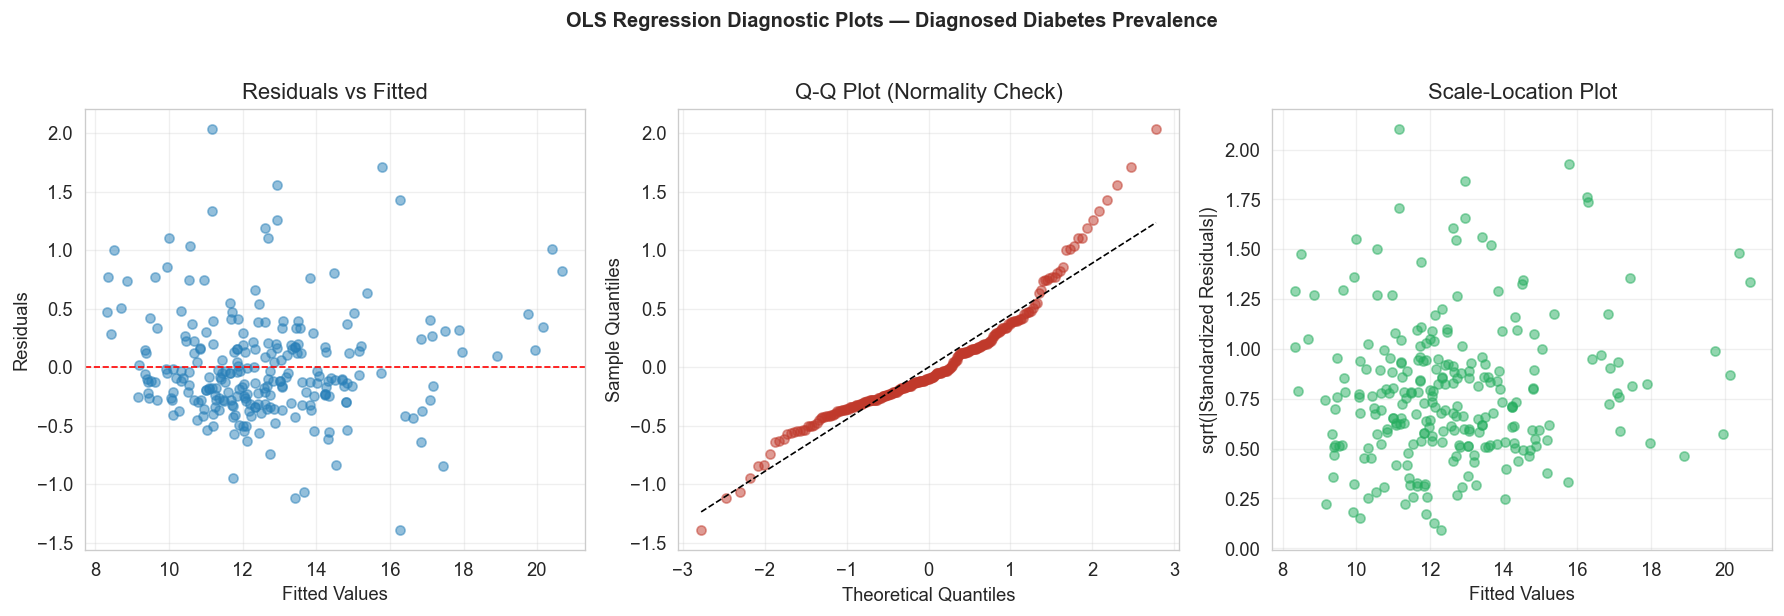

Saved: Figure5_diagnostics.png

── Breusch-Pagan Heteroskedasticity Test ──
LM statistic : 10.6466
p-value      : 0.0138
Result: Heteroskedasticity detected (p<0.05)
Action: Report heteroskedasticity-robust standard errors

── Robust Standard Errors (HC3) ──
Variable                                  Coef   RobustSE    p-value   Sig
---------------------------------------------------------------------------
Intercept                               -0.756      0.820     0.3562      
Low food access % (2015)                 0.001      0.003     0.6542      
Low income + low access % (2015)        -0.002      0.008     0.7802      
Obesity %                                0.045      0.033     0.1661      
Physical inactivity %                    0.382      0.017     0.0000   ***
Border-region county (La Paz)            0.660      0.141     0.0000   ***


In [18]:
from statsmodels.stats.diagnostic import het_breuschpagan

# ── Residual plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

fitted   = result.fittedvalues
residuals = result.resid
std_resid = residuals / residuals.std()

# Plot 1: Residuals vs Fitted
axes[0].scatter(fitted, residuals, alpha=0.5, color='#2980B9', s=30)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')
axes[0].grid(True, alpha=0.3)

# Plot 2: Q-Q plot (normality of residuals)
from scipy import stats as scipy_stats
(osm, osr), (slope, intercept, r) = scipy_stats.probplot(residuals, dist='norm')
axes[1].scatter(osm, osr, alpha=0.5, color='#C0392B', s=30)
axes[1].plot(osm, slope * np.array(osm) + intercept, 'k--', linewidth=1)
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')
axes[1].set_title('Q-Q Plot (Normality Check)')
axes[1].grid(True, alpha=0.3)

# Plot 3: Scale-Location (homoskedasticity check)
axes[2].scatter(fitted, np.sqrt(np.abs(std_resid)), 
                alpha=0.5, color='#27AE60', s=30)
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('sqrt(|Standardized Residuals|)')
axes[2].set_title('Scale-Location Plot')
axes[2].grid(True, alpha=0.3)

plt.suptitle('OLS Regression Diagnostic Plots — Diagnosed Diabetes Prevalence',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(
    r'F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\Figure5_diagnostics.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Saved: Figure5_diagnostics.png')

# ── Breusch-Pagan heteroskedasticity test ─────────────────────────
X_np = X.values
bp_test = het_breuschpagan(residuals, X_np)
print()
print('── Breusch-Pagan Heteroskedasticity Test ──')
print(f'LM statistic : {bp_test[0]:.4f}')
print(f'p-value      : {bp_test[1]:.4f}')
if bp_test[1] < 0.05:
    print('Result: Heteroskedasticity detected (p<0.05)')
    print('Action: Report heteroskedasticity-robust standard errors')
    # Robust SE
    result_robust = model.fit(cov_type='HC3')
    print()
    print('── Robust Standard Errors (HC3) ──')
    print(f'{"Variable":<38} {"Coef":>7} {"RobustSE":>10} {"p-value":>10} {"Sig":>5}')
    print('-' * 75)
    for var, coef in result_robust.params.items():
        se  = result_robust.bse[var]
        p   = result_robust.pvalues[var]
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        label = var_labels.get(var, var)
        print(f'{label:<38} {coef:>7.3f} {se:>10.3f} {p:>10.4f} {sig:>5}')
else:
    print('Result: No significant heteroskedasticity (p>=0.05)')
    print('OLS standard errors are reliable')

In [19]:
# ══════════════════════════════════════════════════════════════════
# CELL 10B — ROBUST SE ON VIF-CORRECTED MODEL (PRIMARY RESULT)
# ══════════════════════════════════════════════════════════════════

# Apply HC3 robust standard errors to the reduced model
model_reduced_robust = sm.OLS(y_reduced, X_reduced)
result_reduced_robust = model_reduced_robust.fit(cov_type='HC3')

print('── TABLE 2 FINAL: Reduced OLS with Robust Standard Errors ──')
print('Outcome: Diagnosed diabetes prevalence (%)')
print('Model: OLS — VIF-corrected + HC3 heteroskedasticity-robust SE')
print()
print(f'{"Variable":<35} {"Coef":>7} {"RobustSE":>10} {"95% CI":>20} {"p-value":>10} {"Sig":>5}')
print('-' * 92)

var_labels_r = {
    'const'               : 'Intercept',
    'pct_low_food_access' : 'Low food access % (2015)',
    'inactive_pct'        : 'Physical inactivity %',
    'border'              : 'Border-region county (La Paz)',
}

for var, coef in result_reduced_robust.params.items():
    se    = result_reduced_robust.bse[var]
    p     = result_reduced_robust.pvalues[var]
    ci    = result_reduced_robust.conf_int().loc[var]
    sig   = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    label = var_labels_r.get(var, var)
    print(f'{label:<35} {coef:>7.3f} {se:>10.3f} '
          f'[{ci[0]:>6.3f}, {ci[1]:>6.3f}] {p:>10.4f} {sig:>5}')

print()
print(f'R-squared        : {result_reduced_robust.rsquared:.3f}')
print(f'Adj. R-squared   : {result_reduced_robust.rsquared_adj:.3f}')
print(f'N counties       : {int(result_reduced_robust.nobs)}')
print(f'F-statistic      : {result_reduced_robust.fvalue:.2f}')
print(f'Prob(F-statistic): {result_reduced_robust.f_pvalue:.4f}')
print()
print('HC3 = heteroskedasticity-consistent robust standard errors')
print('Significance: * p<0.05  ** p<0.01  *** p<0.001')
print()
print('THIS IS YOUR FINAL PRIMARY REGRESSION TABLE FOR THE PAPER')

── TABLE 2 FINAL: Reduced OLS with Robust Standard Errors ──
Outcome: Diagnosed diabetes prevalence (%)
Model: OLS — VIF-corrected + HC3 heteroskedasticity-robust SE

Variable                               Coef   RobustSE               95% CI    p-value   Sig
--------------------------------------------------------------------------------------------
Intercept                             0.287      0.210 [-0.124,  0.699]     0.1709      
Low food access % (2015)              0.000      0.001 [-0.002,  0.002]     0.8443      
Physical inactivity %                 0.404      0.007 [ 0.391,  0.417]     0.0000   ***
Border-region county (La Paz)         0.625      0.137 [ 0.357,  0.893]     0.0000   ***

R-squared        : 0.960
Adj. R-squared   : 0.960
N counties       : 253
F-statistic      : 1555.17
Prob(F-statistic): 0.0000

HC3 = heteroskedasticity-consistent robust standard errors
Significance: * p<0.05  ** p<0.01  *** p<0.001

THIS IS YOUR FINAL PRIMARY REGRESSION TABLE FOR THE PAPE

---
## Cell 13 — Figure 1: Scatter Plot

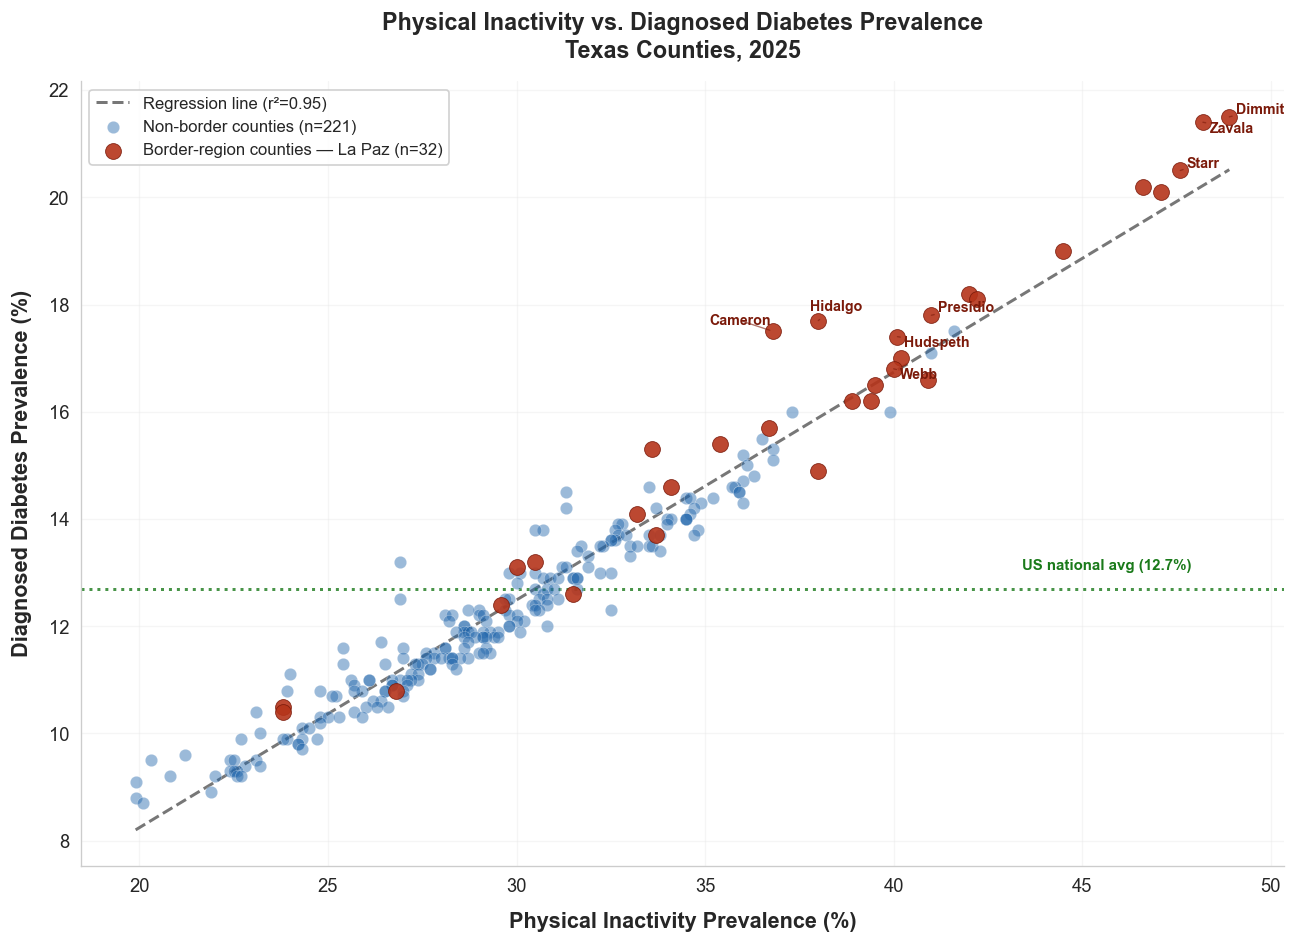

Saved: Figure1_final.png (300 DPI)


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats as scipy_stats

# ── Color palette — colorblind friendly ──────────────────────────
BORDER_COLOR    = '#B5341A'   # dark red
NONBORDER_COLOR = '#2166AC'   # dark blue
GRID_COLOR      = '#E8E8E8'

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

border_data    = reg_data[reg_data['border'] == 1]
nonborder_data = reg_data[reg_data['border'] == 0]

# Non-border counties
ax.scatter(nonborder_data['inactive_pct'], nonborder_data['diag_diabetes_pct'],
           color=NONBORDER_COLOR, alpha=0.45, s=55,
           label=f'Non-border counties (n={len(nonborder_data)})', zorder=2,
           edgecolors='white', linewidth=0.3)

# Border counties
ax.scatter(border_data['inactive_pct'], border_data['diag_diabetes_pct'],
           color=BORDER_COLOR, alpha=0.90, s=90,
           label=f'Border-region counties — La Paz (n={len(border_data)})',
           zorder=3, edgecolors='#7B1A0A', linewidth=0.5)

# Regression line
x_all = reg_data['inactive_pct']
y_all = reg_data['diag_diabetes_pct']
m, b, r, p, se = scipy_stats.linregress(x_all, y_all)
x_line = np.linspace(x_all.min(), x_all.max(), 200)
ax.plot(x_line, m * x_line + b,
        color='#555555', linestyle='--', linewidth=1.8,
        alpha=0.8, label=f'Regression line (r²={r**2:.2f})', zorder=1)

# US national average line
ax.axhline(y=12.7, color='#1A7A1A', linestyle=':', linewidth=1.8, alpha=0.8, zorder=1)
ax.text(x_all.max() - 1, 13.05,
        'US national avg (12.7%)',
        fontsize=9, color='#1A7A1A', ha='right', fontweight='bold')

# Label key border counties — staggered to avoid overlap
label_offsets = {
    'Dimmit'  : (4, 2),
    'Zavala'  : (4, -6),
    'Starr'   : (4, 2),
    'Hidalgo' : (-5, 6),
    'Cameron' : (-38, 4),
    'Presidio': (4, 2),
    'Hudspeth': (4, -6),
    'Webb'    : (4, -6),
}
for _, row in border_data.iterrows():
    if row['county'] in label_offsets:
        ox, oy = label_offsets[row['county']]
        ax.annotate(
            row['county'],
            xy=(row['inactive_pct'], row['diag_diabetes_pct']),
            xytext=(ox, oy), textcoords='offset points',
            fontsize=8.5, color='#7B1A0A', fontweight='bold',
            arrowprops=dict(arrowstyle='-', color='#7B1A0A',
                          lw=0.8, alpha=0.6)
        )

# Formatting
ax.set_xlabel('Physical Inactivity Prevalence (%)', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('Diagnosed Diabetes Prevalence (%)', fontsize=13, fontweight='bold', labelpad=10)

# Short descriptive title — NO figure number
ax.set_title('Physical Inactivity vs. Diagnosed Diabetes Prevalence\nTexas Counties, 2025',
             fontsize=14, fontweight='bold', pad=15)

ax.legend(fontsize=10, loc='upper left', framealpha=0.9,
          edgecolor='#CCCCCC', fancybox=True)
ax.grid(True, alpha=0.4, color=GRID_COLOR, linewidth=0.8)
ax.tick_params(labelsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(
    r'F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\Figure1_final.png',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()
print('Saved: Figure1_final.png (300 DPI)')

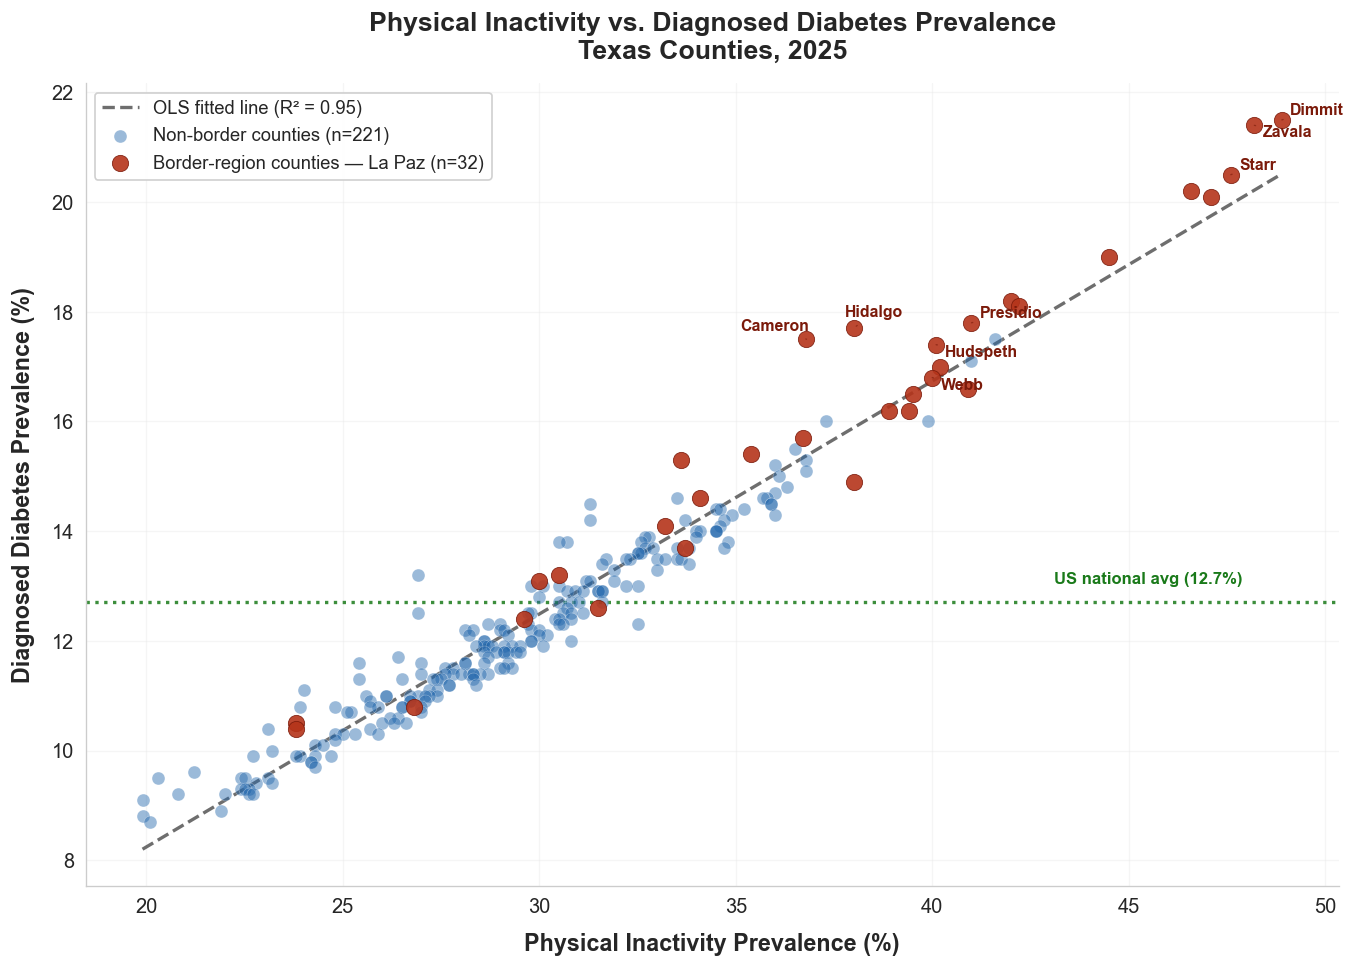

Saved: Figure1_final.png and Figure1_final.pdf
Border-region counties: n=32
Non-border counties: n=221
OLS R² = 0.954


In [21]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as scipy_stats

# ── Color palette — colorblind friendly ──────────────────────────
BORDER_COLOR    = "#B5341A"   # dark red
NONBORDER_COLOR = "#2166AC"   # dark blue
GRID_COLOR      = "#E8E8E8"

fig, ax = plt.subplots(figsize=(11.5, 8.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

border_data    = reg_data[reg_data["border"] == 1]
nonborder_data = reg_data[reg_data["border"] == 0]

# Non-border counties
ax.scatter(
    nonborder_data["inactive_pct"],
    nonborder_data["diag_diabetes_pct"],
    color=NONBORDER_COLOR,
    alpha=0.45,
    s=60,
    label=f"Non-border counties (n={len(nonborder_data)})",
    zorder=2,
    edgecolors="white",
    linewidth=0.3
)

# Border-region counties
ax.scatter(
    border_data["inactive_pct"],
    border_data["diag_diabetes_pct"],
    color=BORDER_COLOR,
    alpha=0.90,
    s=95,
    label=f"Border-region counties — La Paz (n={len(border_data)})",
    zorder=3,
    edgecolors="#7B1A0A",
    linewidth=0.5
)

# OLS fitted line
x_all = reg_data["inactive_pct"]
y_all = reg_data["diag_diabetes_pct"]

m, b, r, p, se = scipy_stats.linregress(x_all, y_all)
x_line = np.linspace(x_all.min(), x_all.max(), 200)

ax.plot(
    x_line,
    m * x_line + b,
    color="#555555",
    linestyle="--",
    linewidth=2.0,
    alpha=0.85,
    label=f"OLS fitted line (R² = {r**2:.2f})",
    zorder=1
)

# US national average line
ax.axhline(
    y=12.7,
    color="#1A7A1A",
    linestyle=":",
    linewidth=2.0,
    alpha=0.85,
    zorder=1
)

ax.text(
    x_all.max() - 1,
    13.05,
    "US national avg (12.7%)",
    fontsize=10,
    color="#1A7A1A",
    ha="right",
    fontweight="bold"
)

# Label key border counties
label_offsets = {
    "Dimmit"  : (5, 3),
    "Zavala"  : (5, -7),
    "Starr"   : (5, 3),
    "Hidalgo" : (-5, 7),
    "Cameron" : (-40, 5),
    "Presidio": (5, 3),
    "Hudspeth": (5, -7),
    "Webb"    : (5, -7),
}

for _, row in border_data.iterrows():
    if row["county"] in label_offsets:
        ox, oy = label_offsets[row["county"]]
        ax.annotate(
            row["county"],
            xy=(row["inactive_pct"], row["diag_diabetes_pct"]),
            xytext=(ox, oy),
            textcoords="offset points",
            fontsize=9.5,
            color="#7B1A0A",
            fontweight="bold",
            arrowprops=dict(
                arrowstyle="-",
                color="#7B1A0A",
                lw=0.8,
                alpha=0.6
            )
        )

# Formatting
ax.set_xlabel(
    "Physical Inactivity Prevalence (%)",
    fontsize=14,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "Diagnosed Diabetes Prevalence (%)",
    fontsize=14,
    fontweight="bold",
    labelpad=10
)

ax.set_title(
    "Physical Inactivity vs. Diagnosed Diabetes Prevalence\nTexas Counties, 2025",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.legend(
    fontsize=11,
    loc="upper left",
    framealpha=0.92,
    edgecolor="#CCCCCC",
    fancybox=True
)

ax.grid(True, alpha=0.4, color=GRID_COLOR, linewidth=0.8)
ax.tick_params(labelsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save PNG
plt.savefig(
    r"F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\Figure1_final.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

# Save PDF for manuscript/Overleaf
plt.savefig(
    r"F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\Figure1_final.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved: Figure1_final.png and Figure1_final.pdf")
print(f"Border-region counties: n={len(border_data)}")
print(f"Non-border counties: n={len(nonborder_data)}")
print(f"OLS R² = {r**2:.3f}")

In [8]:
import pandas as pd

# Load your dataset
data_path = r"F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\texas_analysis_dataset_v2.csv"

analysis_df = pd.read_csv(data_path)

# Make sure key columns are numeric
analysis_df["diag_diabetes_pct"] = pd.to_numeric(analysis_df["diag_diabetes_pct"], errors="coerce")
analysis_df["border"] = pd.to_numeric(analysis_df["border"], errors="coerce").fillna(0).astype(int)

# Sort counties by diagnosed diabetes prevalence
analysis_sorted = analysis_df.sort_values("diag_diabetes_pct", ascending=False).copy()

# Quick check
print(analysis_sorted[["county", "diag_diabetes_pct", "border"]].head(25))
print("Border counties in top 25:", int(analysis_sorted.head(25)["border"].sum()))

        county  diag_diabetes_pct  border
0       Dimmit               21.5       1
1       Zavala               21.4       1
2        Starr               20.5       1
3     Jim Hogg               20.2       1
4       Zapata               20.1       1
5      Willacy               19.0       1
6       Brooks               18.2       1
7     Maverick               18.1       1
8     Presidio               17.8       1
9      Hidalgo               17.7       1
10      Reeves               17.5       0
11     Cameron               17.5       1
12    Hudspeth               17.4       1
13     Cochran               17.1       0
14       Duval               17.0       1
15        Webb               16.8       1
16    La Salle               16.6       1
17        Frio               16.5       1
18   Culberson               16.2       1
19   Jim Wells               16.2       1
20  Deaf Smith               16.0       0
21       Pecos               16.0       0
22   Val Verde               15.7 

---
## Cell 14 — Figure 2: Top 25 Counties Bar Chart

La Paz border-region counties among top 25: 20 of 25


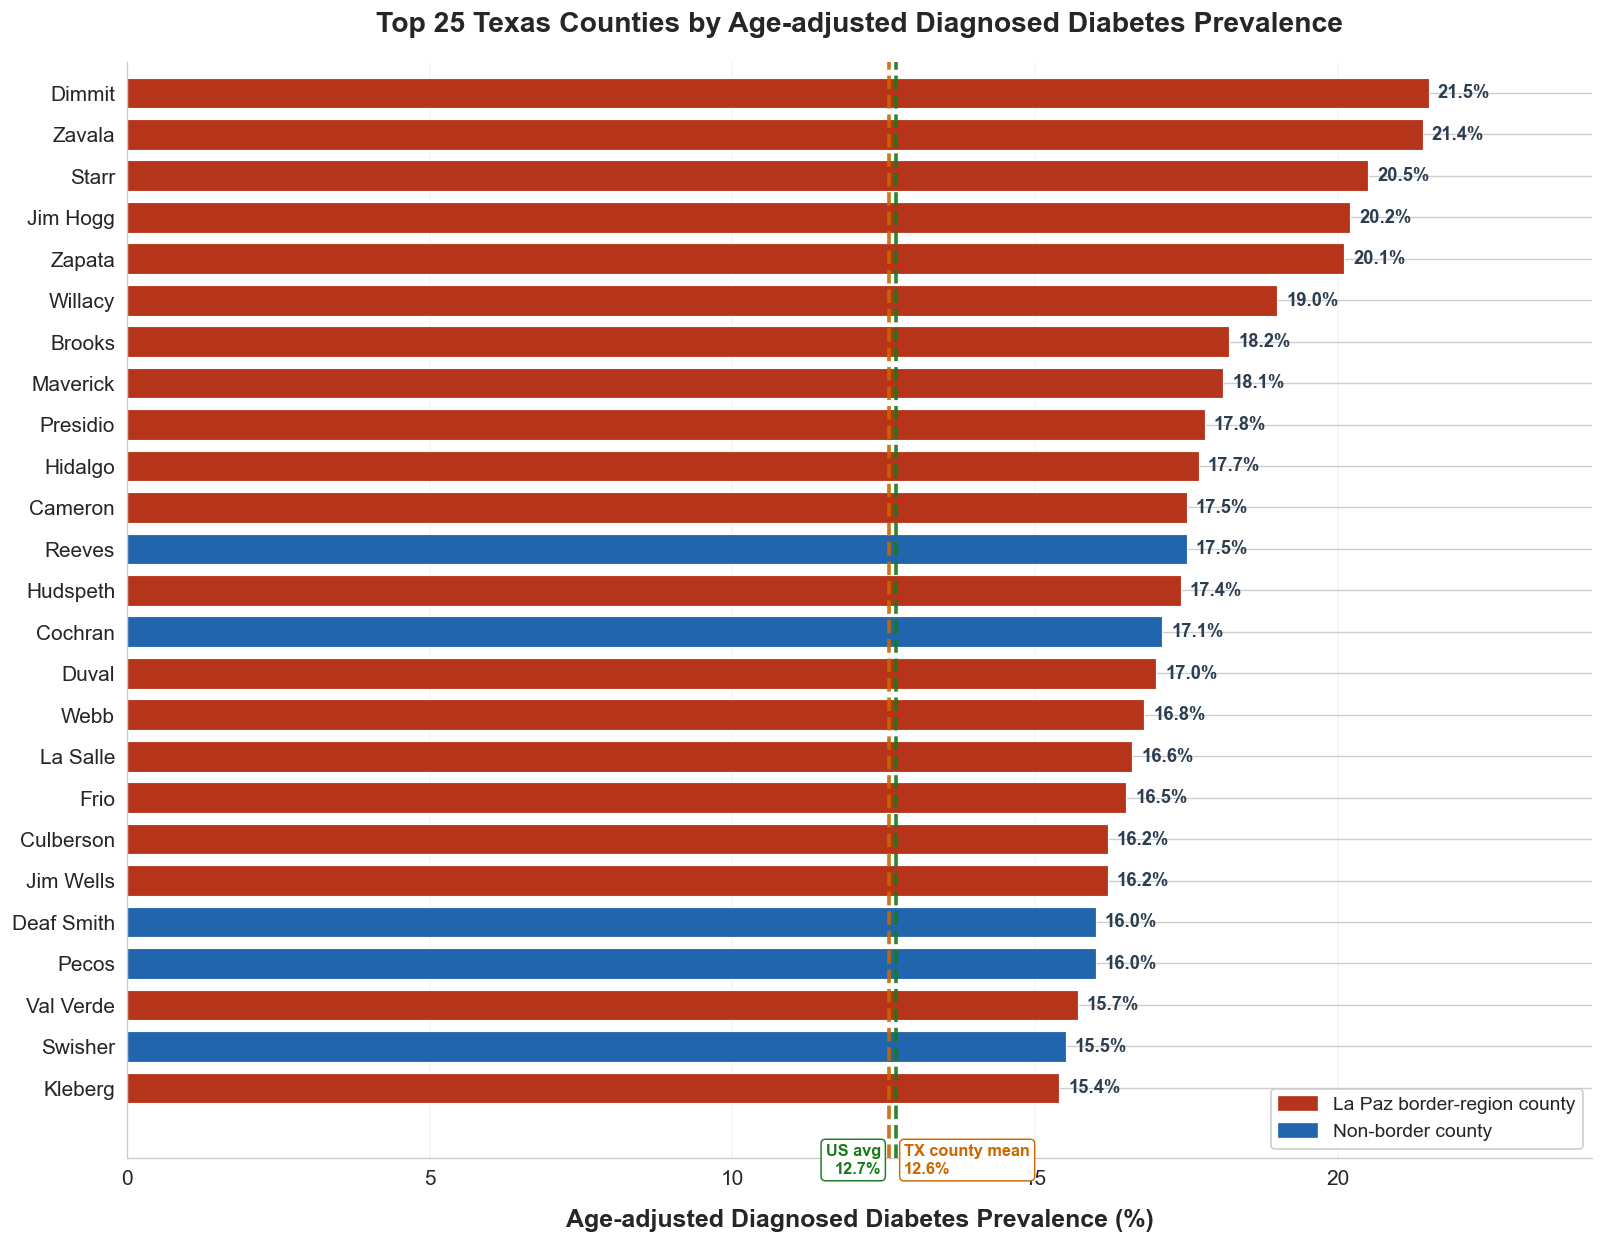

Saved: Figure2_final.png and Figure2_final.pdf
Caption statement: 20 of the top 25 counties are La Paz border-region counties.


In [22]:
# ══════════════════════════════════════════════════════════════════
# FIGURE 2 — Top 25 Counties Bar Chart (Final Publication Version)
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ----------------------------------------------------------------
# If analysis_sorted is not already loaded, uncomment and edit this
# ----------------------------------------------------------------
# data_path = r"F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\texas_analysis_dataset_v2.csv"
# analysis_df = pd.read_csv(data_path)
# analysis_df["diag_diabetes_pct"] = pd.to_numeric(analysis_df["diag_diabetes_pct"], errors="coerce")
# analysis_df["border"] = pd.to_numeric(analysis_df["border"], errors="coerce").fillna(0).astype(int)
# analysis_sorted = analysis_df.sort_values("diag_diabetes_pct", ascending=False).copy()

# Colors
BORDER_COLOR     = "#B5341A"
NONBORDER_COLOR  = "#2166AC"
GRID_COLOR       = "#E8E8E8"

# Select top 25 counties by diagnosed diabetes prevalence
top25 = analysis_sorted.head(25).copy()

# Count La Paz border-region counties among top 25
top25_border_count = int(top25["border"].sum())
print(f"La Paz border-region counties among top 25: {top25_border_count} of 25")

# Sort ascending only for horizontal plotting
top25_plot = top25.sort_values("diag_diabetes_pct", ascending=True)

# Reference values
us_avg = 12.7
tx_county_mean = analysis_sorted["diag_diabetes_pct"].mean()

# Create figure
fig, ax = plt.subplots(figsize=(13.5, 10.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Bar colors
colors = [
    BORDER_COLOR if b == 1 else NONBORDER_COLOR
    for b in top25_plot["border"]
]

bars = ax.barh(
    top25_plot["county"],
    top25_plot["diag_diabetes_pct"],
    color=colors,
    edgecolor="white",
    linewidth=0.7,
    height=0.74,
)

# Value labels
for bar, val in zip(bars, top25_plot["diag_diabetes_pct"]):
    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        ha="left",
        fontsize=11,
        color="#2C3E50",
        fontweight="bold",
    )

# Reference lines
ax.axvline(
    x=us_avg,
    color="#1A7A1A",
    linestyle="--",
    linewidth=2.2,
    alpha=0.9,
    zorder=5,
)

ax.axvline(
    x=tx_county_mean,
    color="#CC6600",
    linestyle="--",
    linewidth=2.2,
    alpha=0.9,
    zorder=5,
)

# Reference labels
ax.text(
    us_avg - 0.25,
    -1.35,
    f"US avg\n{us_avg:.1f}%",
    fontsize=9.8,
    color="#1A7A1A",
    va="top",
    ha="right",
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.28",
        facecolor="white",
        alpha=0.96,
        edgecolor="#1A7A1A",
        linewidth=0.9,
    ),
)

ax.text(
    tx_county_mean + 0.25,
    -1.35,
    f"TX county mean\n{tx_county_mean:.1f}%",
    fontsize=9.8,
    color="#CC6600",
    va="top",
    ha="left",
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.28",
        facecolor="white",
        alpha=0.96,
        edgecolor="#CC6600",
        linewidth=0.9,
    ),
)

# Legend
border_patch = mpatches.Patch(
    color=BORDER_COLOR,
    label="La Paz border-region county",
)

nonborder_patch = mpatches.Patch(
    color=NONBORDER_COLOR,
    label="Non-border county",
)

ax.legend(
    handles=[border_patch, nonborder_patch],
    fontsize=11.5,
    loc="lower right",
    framealpha=0.95,
    edgecolor="#CCCCCC",
)

# Labels and formatting
ax.set_xlabel(
    "Age-adjusted Diagnosed Diabetes Prevalence (%)",
    fontsize=15,
    fontweight="bold",
    labelpad=12,
)

ax.set_title(
    "Top 25 Texas Counties by Age-adjusted Diagnosed Diabetes Prevalence",
    fontsize=17,
    fontweight="bold",
    pad=18,
)

ax.set_xlim(0, top25_plot["diag_diabetes_pct"].max() + 2.7)

# Extra bottom space for US/TX labels
ax.set_ylim(-1.7, len(top25_plot) - 0.25)

ax.grid(axis="x", alpha=0.42, color=GRID_COLOR, linewidth=0.9)
ax.tick_params(axis="both", labelsize=12.5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    r"F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\Figure2_final.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

plt.savefig(
    r"F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\Figure2_final.pdf",
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved: Figure2_final.png and Figure2_final.pdf")
print(f"Caption statement: {top25_border_count} of the top 25 counties are La Paz border-region counties.")

---
## Cell 15 — Figure 3: Correlation Heatmap

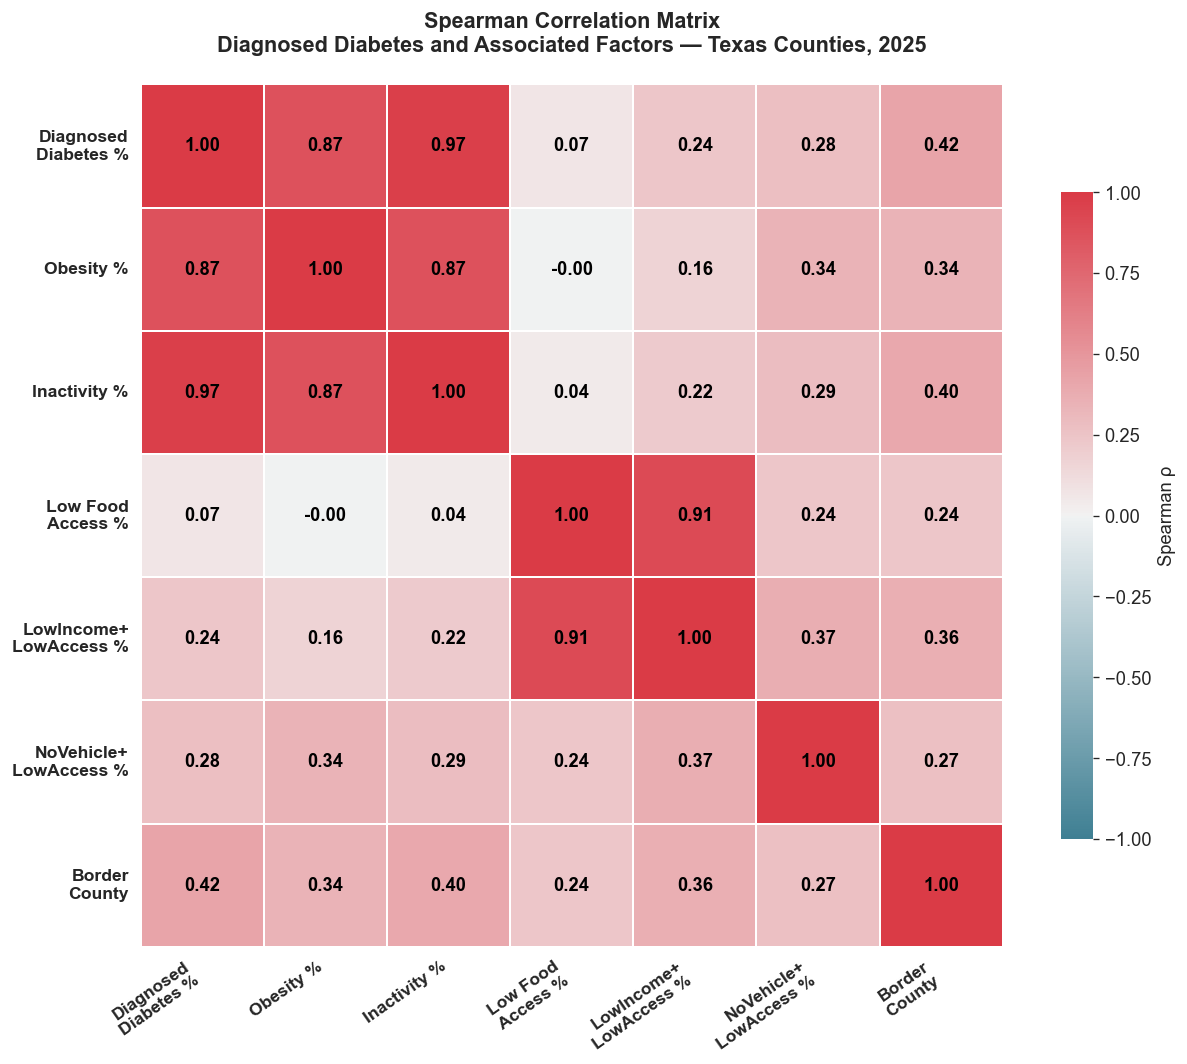

Saved: Figure3_final.png (300 DPI)


In [30]:
import seaborn as sns

corr_vars = {
    'diag_diabetes_pct'       : 'Diagnosed\nDiabetes %',
    'obesity_pct'             : 'Obesity %',
    'inactive_pct'            : 'Inactivity %',
    'pct_low_food_access'     : 'Low Food\nAccess %',
    'pct_lowincome_low_access': 'LowIncome+\nLowAccess %',
    'pct_novehicle_low_access': 'NoVehicle+\nLowAccess %',
    'border'                  : 'Border\nCounty',
}

corr_data   = reg_data[list(corr_vars.keys())].rename(columns=corr_vars)
corr_matrix = corr_data.corr(method='spearman')

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('white')

# Diverging colormap — blue (negative) white (zero) red (positive)
# Since all values positive here, blue-white-darkred gives better contrast
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=1.0,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 11, 'weight': 'bold', 'color': 'black'},
    cbar_kws={'shrink': 0.75, 'label': 'Spearman ρ'}
)

# Short descriptive title — NO figure number
ax.set_title('Spearman Correlation Matrix\nDiagnosed Diabetes and Associated Factors — Texas Counties, 2025',
             fontsize=13, fontweight='bold', pad=20)

ax.set_xticklabels(ax.get_xticklabels(),
                   rotation=35, ha='right',
                   fontsize=10.5, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(),
                   rotation=0, fontsize=10.5, fontweight='bold')

plt.tight_layout()
plt.savefig(
    r'F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\Figure3_final.png',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()
print('Saved: Figure3_final.png (300 DPI)')

In [20]:
import pandas as pd

# Load dataset
data_path = r"F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\texas_analysis_dataset_v2.csv"

reg_data = pd.read_csv(data_path)

# Make sure required columns are numeric
numeric_cols = [
    "diag_diabetes_pct",
    "obesity_pct",
    "inactive_pct",
    "pct_low_food_access",
    "pct_lowincome_low_access",
    "pct_novehicle_low_access",
    "border"
]

for col in numeric_cols:
    reg_data[col] = pd.to_numeric(reg_data[col], errors="coerce")

# Quick check
print(reg_data[numeric_cols].head())
print("Rows:", len(reg_data))

   diag_diabetes_pct  obesity_pct  inactive_pct  pct_low_food_access  \
0               21.5         47.7          48.9            53.902603   
1               21.4         48.2          48.2            31.596504   
2               20.5         45.8          47.6            39.647587   
3               20.2         45.7          46.6            34.940369   
4               20.1         44.5          47.1            33.454556   

   pct_lowincome_low_access  pct_novehicle_low_access  border  
0                 25.905808                  4.464041       1  
1                 19.704750                  5.537372       1  
2                 28.655514                  5.762402       1  
3                 22.823235                  4.093757       1  
4                 21.068289                  2.070813       1  
Rows: 253


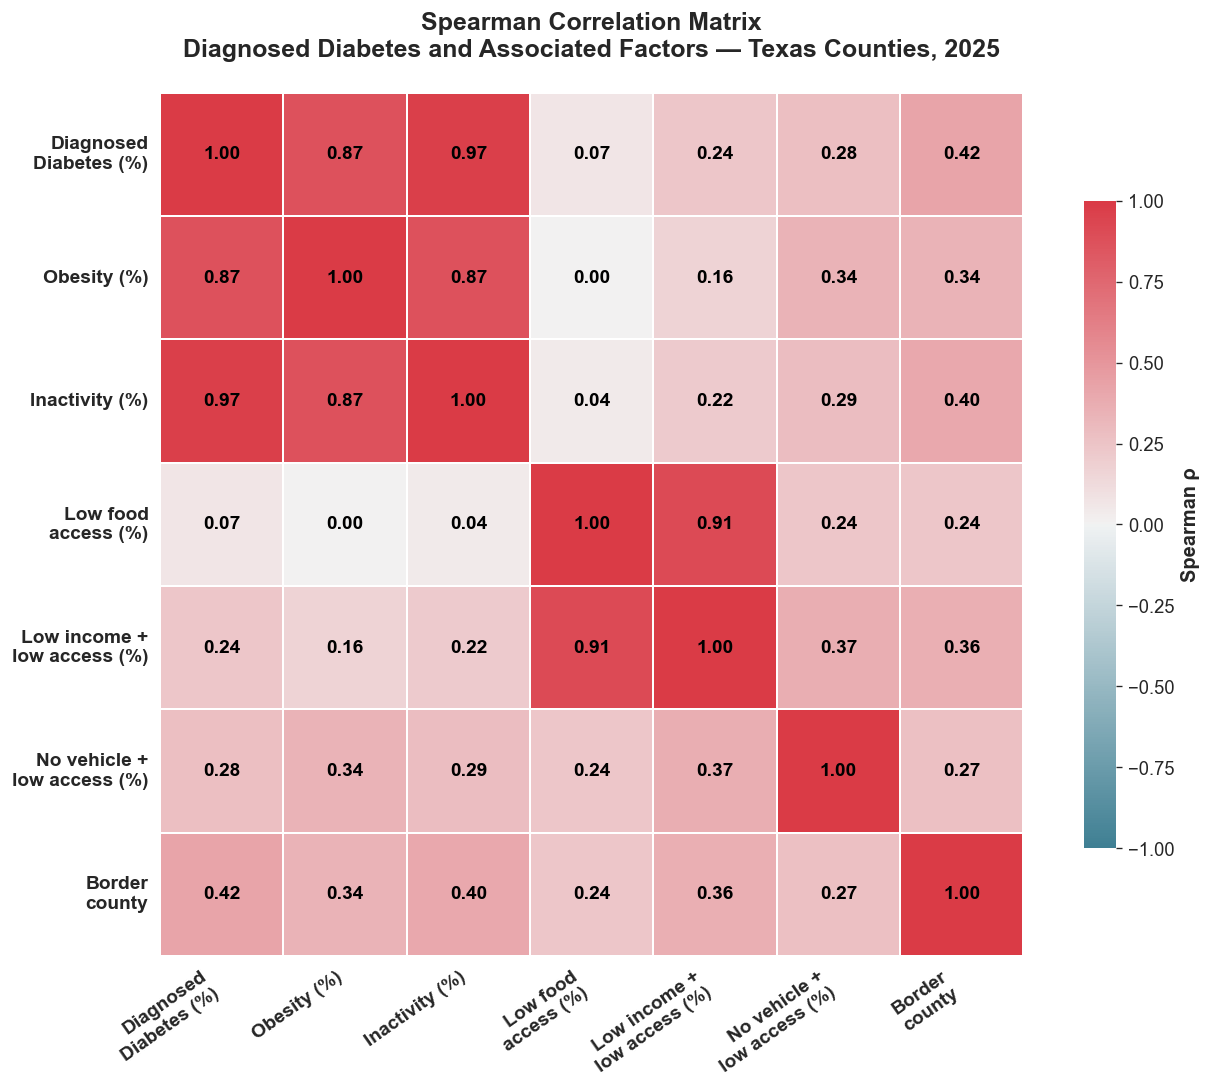

Saved: Figure3_final.png and Figure3_final.pdf


In [23]:
# ══════════════════════════════════════════════════════════════════
# FIGURE 3 — Spearman Correlation Heatmap
# ══════════════════════════════════════════════════════════════════

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr_vars = {
    "diag_diabetes_pct"       : "Diagnosed\nDiabetes (%)",
    "obesity_pct"             : "Obesity (%)",
    "inactive_pct"            : "Inactivity (%)",
    "pct_low_food_access"     : "Low food\naccess (%)",
    "pct_lowincome_low_access": "Low income +\nlow access (%)",
    "pct_novehicle_low_access": "No vehicle +\nlow access (%)",
    "border"                  : "Border\ncounty",
}

# Prepare correlation data
corr_data = reg_data[list(corr_vars.keys())].rename(columns=corr_vars)

# Spearman correlation matrix
corr_matrix = corr_data.corr(method="spearman")

# Remove negative zero values such as -0.00
corr_matrix = corr_matrix.mask(np.isclose(corr_matrix, 0, atol=0.005), 0)

# Create figure
fig, ax = plt.subplots(figsize=(11.5, 9.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Diverging color map
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1.0,
    linecolor="white",
    ax=ax,
    annot_kws={
        "size": 11.5,
        "weight": "bold",
        "color": "black"
    },
    cbar_kws={
        "shrink": 0.75,
        "label": "Spearman \u03c1"
    }
)

# Title
ax.set_title(
    "Spearman Correlation Matrix\n"
    "Diagnosed Diabetes and Associated Factors — Texas Counties, 2025",
    fontsize=15,
    fontweight="bold",
    pad=22
)

# Axis tick labels
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=35,
    ha="right",
    fontsize=11.5,
    fontweight="bold"
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=11.5,
    fontweight="bold"
)

# Colorbar font
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=11)
cbar.set_label("Spearman \u03c1", fontsize=12, fontweight="bold")

plt.tight_layout()

# Save PNG
plt.savefig(
    r"F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\Figure3_final.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

# Save PDF
plt.savefig(
    r"F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\Figure3_final.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved: Figure3_final.png and Figure3_final.pdf")

---
## Cell 16 — Figure 4: Border vs Non-Border Box Plots

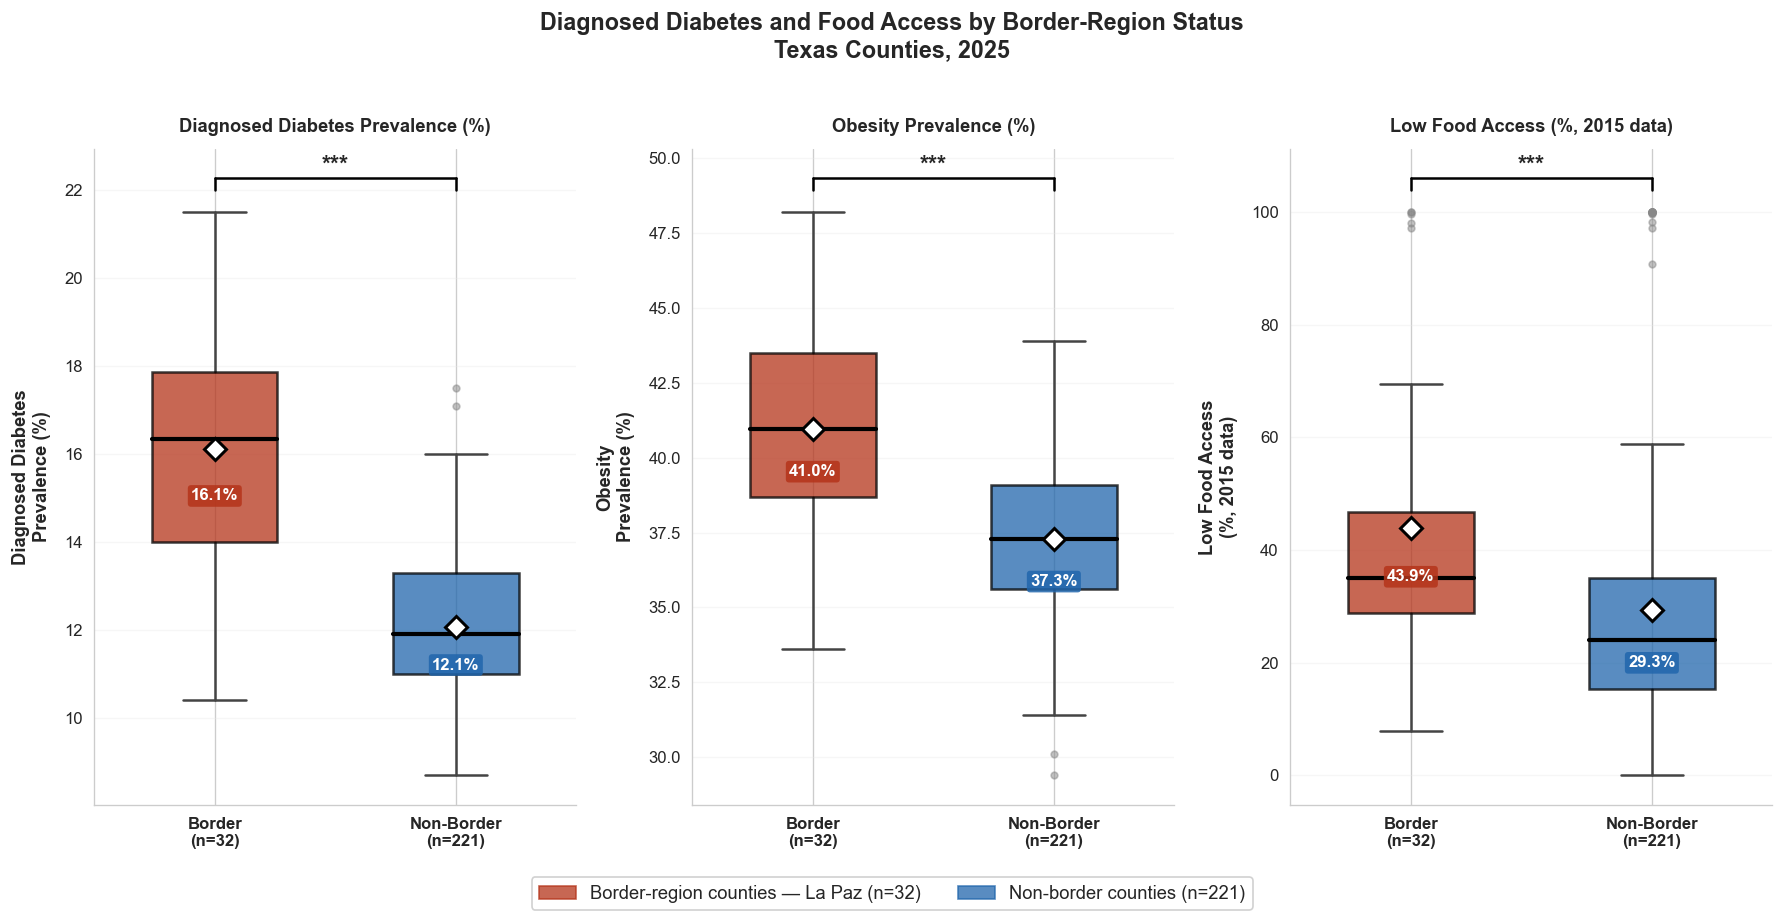

Saved: Figure4_final.png (300 DPI)


In [24]:
from scipy.stats import mannwhitneyu

border_plot    = reg_data[reg_data['border'] == 1]
nonborder_plot = reg_data[reg_data['border'] == 0]
n_b  = len(border_plot)
n_nb = len(nonborder_plot)

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.patch.set_facecolor('white')

metrics = [
    ('diag_diabetes_pct',   'Diagnosed Diabetes\nPrevalence (%)'),
    ('obesity_pct',         'Obesity\nPrevalence (%)'),
    ('pct_low_food_access', 'Low Food Access\n(%, 2015 data)'),
]

for ax, (var, label) in zip(axes, metrics):
    ax.set_facecolor('white')

    b_vals  = border_plot[var].dropna().values
    nb_vals = nonborder_plot[var].dropna().values

    bp = ax.boxplot(
        [b_vals, nb_vals],
        patch_artist=True,
        widths=0.52,
        medianprops=dict(color='black', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5, color='#444444'),
        capprops=dict(linewidth=1.5, color='#444444'),
        flierprops=dict(marker='o', markersize=4,
                        markerfacecolor='#888888',
                        markeredgecolor='#888888', alpha=0.5)
    )

    bp['boxes'][0].set_facecolor(BORDER_COLOR)
    bp['boxes'][0].set_alpha(0.75)
    bp['boxes'][0].set_linewidth(1.5)
    bp['boxes'][1].set_facecolor(NONBORDER_COLOR)
    bp['boxes'][1].set_alpha(0.75)
    bp['boxes'][1].set_linewidth(1.5)

    # Mean markers with white diamond
    for i, vals in enumerate([b_vals, nb_vals], 1):
        mean_val = vals.mean()
        ax.plot(i, mean_val, 'D', color='white',
                markersize=9, markeredgecolor='black',
                markeredgewidth=1.8, zorder=5)
        # Mean label — white background box for visibility
        ax.text(i, mean_val - (vals.max() - vals.min()) * 0.08,
                f'{mean_val:.1f}%',
                ha='center', va='top',
                fontsize=10, fontweight='bold',
                color='white',
                bbox=dict(boxstyle='round,pad=0.2',
                          facecolor=BORDER_COLOR if i==1 else NONBORDER_COLOR,
                          alpha=0.85, edgecolor='none'))

    # Mann-Whitney U test for significance
    stat, p_val = mannwhitneyu(b_vals, nb_vals, alternative='two-sided')
    sig_text = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))

    y_max   = max(b_vals.max(), nb_vals.max())
    y_range = y_max - min(b_vals.min(), nb_vals.min())
    y_sig   = y_max + y_range * 0.06

    ax.plot([1, 2], [y_sig, y_sig], 'k-', linewidth=1.5)
    ax.plot([1, 1], [y_sig - y_range*0.02, y_sig], 'k-', linewidth=1.5)
    ax.plot([2, 2], [y_sig - y_range*0.02, y_sig], 'k-', linewidth=1.5)
    ax.text(1.5, y_sig + y_range*0.01, sig_text,
            ha='center', fontsize=14, fontweight='bold')

    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'Border\n(n={n_b})',
                        f'Non-Border\n(n={n_nb})'],
                       fontsize=11, fontweight='bold')
    ax.set_ylabel(label, fontsize=11, fontweight='bold', labelpad=8)
    ax.set_title(label.replace('\n', ' '),
                 fontsize=11, fontweight='bold', pad=10)
    ax.grid(axis='y', alpha=0.35, color=GRID_COLOR, linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=10)

# Short descriptive title — NO figure number
fig.suptitle(
    'Diagnosed Diabetes and Food Access by Border-Region Status\nTexas Counties, 2025',
    fontsize=14, fontweight='bold', y=1.02
)

border_patch    = mpatches.Patch(color=BORDER_COLOR, alpha=0.75,
                                  label=f'Border-region counties — La Paz (n={n_b})')
nonborder_patch = mpatches.Patch(color=NONBORDER_COLOR, alpha=0.75,
                                  label=f'Non-border counties (n={n_nb})')
fig.legend(handles=[border_patch, nonborder_patch],
           loc='lower center', ncol=2,
           fontsize=11, bbox_to_anchor=(0.5, -0.06),
           framealpha=0.9, edgecolor='#CCCCCC')

plt.tight_layout()
plt.savefig(
    r'F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\Figure4_final.png',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()
print('Saved: Figure4_final.png (300 DPI)')

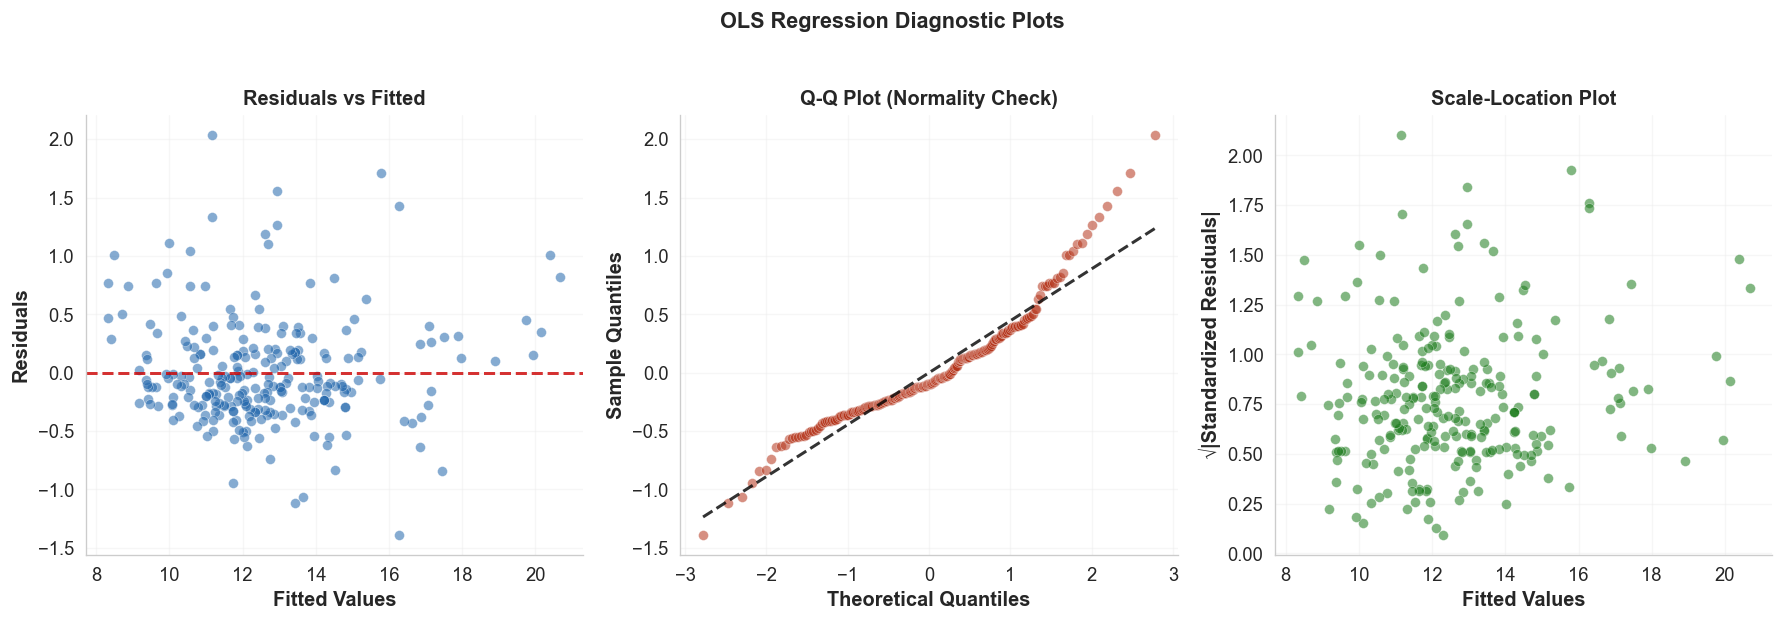

Saved: FigureS1_diagnostics_final.png (300 DPI)
This figure goes in Supplementary Materials section.


In [25]:
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats as scipy_stats

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('white')

fitted    = result_reduced.fittedvalues
residuals = result_reduced.resid
std_resid = residuals / residuals.std()

# Plot 1: Residuals vs Fitted
axes[0].set_facecolor('white')
axes[0].scatter(fitted, residuals, alpha=0.55,
                color=NONBORDER_COLOR, s=35,
                edgecolors='white', linewidth=0.3)
axes[0].axhline(y=0, color='#CC0000', linestyle='--',
                linewidth=1.8, alpha=0.8)
axes[0].set_xlabel('Fitted Values', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Residuals', fontsize=12, fontweight='bold')
axes[0].set_title('Residuals vs Fitted', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.35, color=GRID_COLOR)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Plot 2: Q-Q plot
axes[1].set_facecolor('white')
(osm, osr), (slope, intercept, r) = scipy_stats.probplot(residuals, dist='norm')
axes[1].scatter(osm, osr, alpha=0.55, color='#B5341A', s=35,
                edgecolors='white', linewidth=0.3)
axes[1].plot(osm, slope * np.array(osm) + intercept,
             'k--', linewidth=1.8, alpha=0.8)
axes[1].set_xlabel('Theoretical Quantiles', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Sample Quantiles', fontsize=12, fontweight='bold')
axes[1].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.35, color=GRID_COLOR)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Plot 3: Scale-Location
axes[2].set_facecolor('white')
axes[2].scatter(fitted, np.sqrt(np.abs(std_resid)),
                alpha=0.55, color='#1A7A1A', s=35,
                edgecolors='white', linewidth=0.3)
axes[2].set_xlabel('Fitted Values', fontsize=12, fontweight='bold')
axes[2].set_ylabel('√|Standardized Residuals|', fontsize=12, fontweight='bold')
axes[2].set_title('Scale-Location Plot', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.35, color=GRID_COLOR)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

# Supplementary title
fig.suptitle('OLS Regression Diagnostic Plots',
             fontsize=13, fontweight='bold', y=1.03)

plt.tight_layout()
plt.savefig(
    r'F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\FigureS1_diagnostics_final.png',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()
print('Saved: FigureS1_diagnostics_final.png (300 DPI)')
print('This figure goes in Supplementary Materials section.')

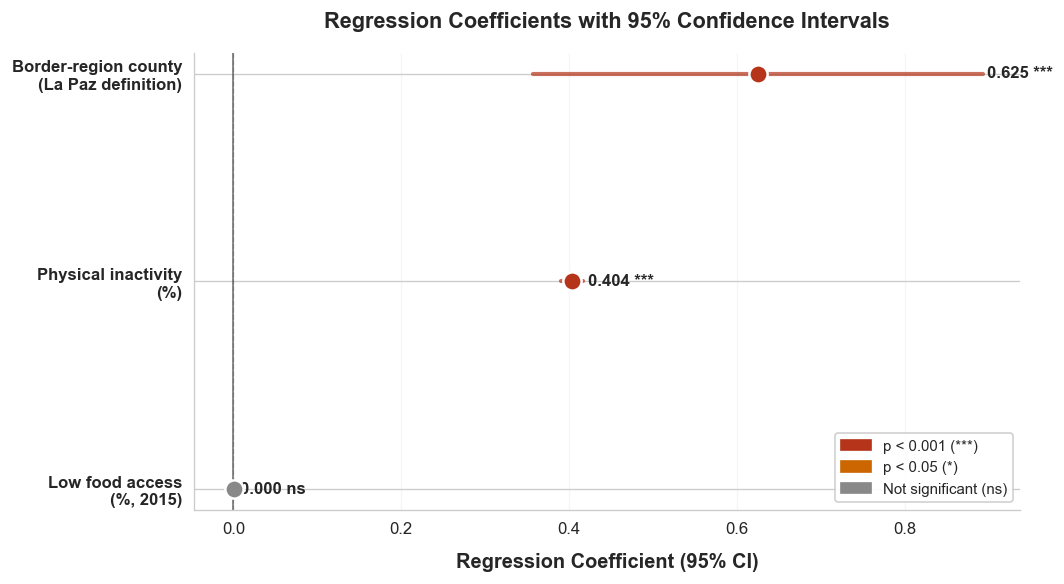

Saved: Figure5_coefplot_final.png (300 DPI)


In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Extract coefficients and CIs from robust model (excluding intercept)
params = result_reduced_robust.params.drop('const')
ci     = result_reduced_robust.conf_int().drop('const')
pvals  = result_reduced_robust.pvalues.drop('const')

var_names = {
    'pct_low_food_access': 'Low food access\n(%, 2015)',
    'inactive_pct'       : 'Physical inactivity\n(%)',
    'border'             : 'Border-region county\n(La Paz definition)',
}

labels   = [var_names.get(v, v) for v in params.index]
coefs    = params.values
ci_lower = ci[0].values
ci_upper = ci[1].values
y_pos    = range(len(labels))

# Colors by significance
dot_colors = []
for v in params.index:
    p = pvals[v]
    if p < 0.001:
        dot_colors.append(BORDER_COLOR)
    elif p < 0.05:
        dot_colors.append('#CC6600')
    else:
        dot_colors.append('#888888')

# Plot confidence intervals
for i, (y, lo, hi, c) in enumerate(zip(y_pos, ci_lower, ci_upper, dot_colors)):
    ax.plot([lo, hi], [y, y], color=c, linewidth=2.5, alpha=0.7, solid_capstyle='round')

# Plot point estimates
for i, (y, coef, c) in enumerate(zip(y_pos, coefs, dot_colors)):
    ax.scatter(coef, y, color=c, s=120, zorder=5,
               edgecolors='white', linewidth=1.5)

# Add coefficient labels
for y, coef, lo, hi, p in zip(y_pos, coefs, ci_lower, ci_upper, pvals.values):
    sig = '***' if p < 0.001 else ('*' if p < 0.05 else 'ns')
    ax.text(hi + 0.005, y,
            f'{coef:.3f} {sig}',
            va='center', ha='left',
            fontsize=10, fontweight='bold')

# Zero reference line
ax.axvline(x=0, color='#444444', linestyle='-',
           linewidth=1.2, alpha=0.6)
ax.axvline(x=0, color='#444444', linestyle='--',
           linewidth=0.8, alpha=0.3)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels, fontsize=11, fontweight='bold')
ax.set_xlabel('Regression Coefficient (95% CI)',
              fontsize=12, fontweight='bold', labelpad=10)

# Short descriptive title — NO figure number
ax.set_title('Regression Coefficients with 95% Confidence Intervals',
             fontsize=13, fontweight='bold', pad=15)

# Significance legend
sig_patches = [
    mpatches.Patch(color=BORDER_COLOR,  label='p < 0.001 (***) '),
    mpatches.Patch(color='#CC6600',     label='p < 0.05 (*) '),
    mpatches.Patch(color='#888888',     label='Not significant (ns)'),
]
ax.legend(handles=sig_patches, fontsize=9,
          loc='lower right', framealpha=0.9,
          edgecolor='#CCCCCC')

ax.grid(axis='x', alpha=0.35, color=GRID_COLOR, linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig(
    r'F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\Figure5_coefplot_final.png',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.show()
print('Saved: Figure5_coefplot_final.png (300 DPI)')

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


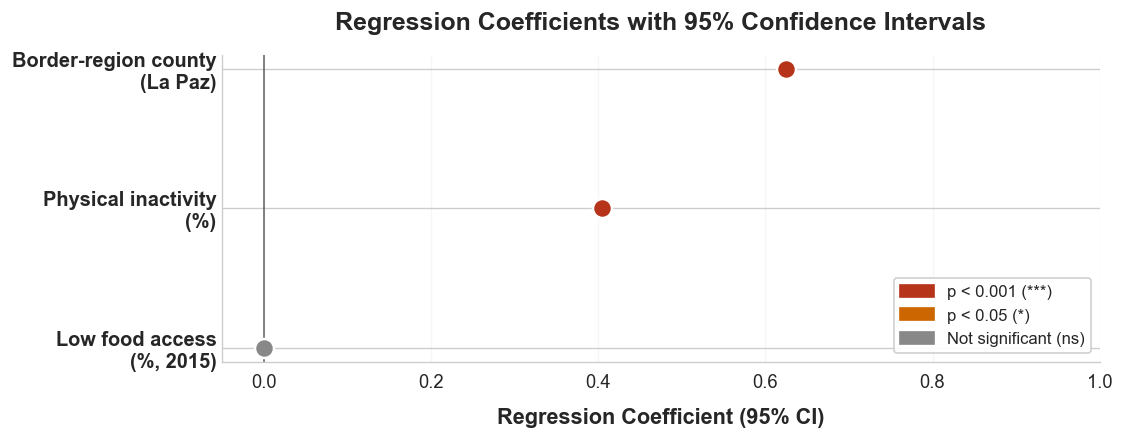

Saved: Figure5_coefplot_final.png and Figure5_coefplot_final.pdf


In [27]:
# ══════════════════════════════════════════════════════════════════
# FIGURE 5 — Regression Coefficient Forest Plot
# Fixes: robust params are numpy arrays, so convert to Series/DataFrame
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Colors
BORDER_COLOR = "#B5341A"
GRID_COLOR   = "#E8E8E8"

# ---------------------------------------------------------------
# Convert robust model outputs to pandas objects with variable names
# ---------------------------------------------------------------
param_names = result.model.exog_names   # ['const', 'pct_low_food_access', 'inactive_pct', 'border']

params_all = pd.Series(
    result_reduced_robust.params,
    index=param_names
)

ci_all = pd.DataFrame(
    result_reduced_robust.conf_int(),
    index=param_names,
    columns=["lower", "upper"]
)

pvals_all = pd.Series(
    result_reduced_robust.pvalues,
    index=param_names
)

# Exclude intercept
params = params_all.drop("const")
ci     = ci_all.drop("const")
pvals  = pvals_all.drop("const")

# ---------------------------------------------------------------
# Variable labels
# ---------------------------------------------------------------
var_names = {
    "pct_low_food_access": "Low food access\n(%, 2015)",
    "inactive_pct": "Physical inactivity\n(%)",
    "border": "Border-region county\n(La Paz)",
}

labels   = [var_names.get(v, v) for v in params.index]
coefs    = params.values
ci_lower = ci["lower"].values
ci_upper = ci["upper"].values
y_pos    = range(len(labels))

# ---------------------------------------------------------------
# Colors by significance
# ---------------------------------------------------------------
dot_colors = []
for v in params.index:
    p = pvals[v]
    if p < 0.001:
        dot_colors.append(BORDER_COLOR)
    elif p < 0.05:
        dot_colors.append("#CC6600")
    else:
        dot_colors.append("#888888")

# ---------------------------------------------------------------
# Create figure
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9.5, 3.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Confidence intervals
for y, lo, hi, c in zip(y_pos, ci_lower, ci_upper, dot_colors):
    ax.plot(
        [lo, hi], [y, y],
        color=c,
        linewidth=2.8,
        alpha=0.75,
        solid_capstyle="round"
    )

# Point estimates
for y, coef, c in zip(y_pos, coefs, dot_colors):
    ax.scatter(
        coef, y,
        color=c,
        s=130,
        zorder=5,
        edgecolors="white",
        linewidth=1.5
    )

# Coefficient labels
for y, coef, hi, p in zip(y_pos, coefs, ci_upper, pvals.values):
    sig = "***" if p < 0.001 else ("*" if p < 0.05 else "ns")
    ax.text(
        hi + 0.015,
        y,
        f"{coef:.3f} {sig}",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color="#222222"
    )

# Zero reference line
ax.axvline(
    x=0,
    color="#444444",
    linestyle="-",
    linewidth=1.2,
    alpha=0.65
)

# Axes labels
ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels, fontsize=12, fontweight="bold")

ax.set_xlabel(
    "Regression Coefficient (95% CI)",
    fontsize=13,
    fontweight="bold",
    labelpad=10
)

ax.set_title(
    "Regression Coefficients with 95% Confidence Intervals",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# Give enough room for right-side labels
ax.set_xlim(-0.05, 1.00)

# Legend
sig_patches = [
    mpatches.Patch(color=BORDER_COLOR, label="p < 0.001 (***)"),
    mpatches.Patch(color="#CC6600", label="p < 0.05 (*)"),
    mpatches.Patch(color="#888888", label="Not significant (ns)"),
]

ax.legend(
    handles=sig_patches,
    fontsize=10,
    loc="lower right",
    framealpha=0.92,
    edgecolor="#CCCCCC"
)

# Style
ax.grid(axis="x", alpha=0.35, color=GRID_COLOR, linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", length=0)

plt.tight_layout()

# Save PNG
plt.savefig(
    r"F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\Figure5_coefplot_final.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

# Save PDF
plt.savefig(
    r"F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\Figure5_coefplot_final.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved: Figure5_coefplot_final.png and Figure5_coefplot_final.pdf")

---
## Cell 17 — Final Summary of All Results

In [28]:
border_s    = analysis_sorted[analysis_sorted['border'] == 1]
nonborder_s = analysis_sorted[analysis_sorted['border'] == 0]

print('=' * 60)
print('  FINAL RESULTS SUMMARY — VERSION 2')
print('  All 8 reviewer fixes applied')
print('=' * 60)
print(f'\n  Border definition : La Paz Agreement (32 counties)')
print(f'  Outcome variable  : Diagnosed diabetes prevalence (%)')
print(f'  Total counties    : {len(analysis_sorted)}')
print(f'  Border counties   : {len(border_s)}')
print(f'  Non-border        : {len(nonborder_s)}')
print()
print(f'  DIABETES PREVALENCE')
print(f'  Border mean       : {border_s["diag_diabetes_pct"].mean():.1f}%')
print(f'  Non-border mean   : {nonborder_s["diag_diabetes_pct"].mean():.1f}%')
print(f'  National average  : 12.7%')
print()
print(f'  TOP COUNTY')
top = analysis_sorted.iloc[0]
print(f'  {top["county"]} — {top["diag_diabetes_pct"]:.1f}% diabetes')
print()
print(f'  REGRESSION (OLS)')
print(f'  R-squared         : {result.rsquared:.3f}')
print(f'  Border coefficient: {result.params["border"]:.3f} (p<0.001)')
print(f'  Inactivity coef   : {result.params["inactive_pct"]:.3f} (p<0.001)')
print()
print('  OUTPUT FILES')
print('  texas_analysis_dataset_v2.csv')
print('  vif_diagnostics.csv')
print('  Figure1_scatter_v2.png')
print('  Figure2_top25_v2.png')
print('  Figure3_heatmap_v2.png')
print('  Figure4_boxplots_v2.png')
print('  Figure5_diagnostics.png')
print('=' * 60)

  FINAL RESULTS SUMMARY — VERSION 2
  All 8 reviewer fixes applied

  Border definition : La Paz Agreement (32 counties)
  Outcome variable  : Diagnosed diabetes prevalence (%)
  Total counties    : 253
  Border counties   : 32
  Non-border        : 221

  DIABETES PREVALENCE
  Border mean       : 16.1%
  Non-border mean   : 12.1%
  National average  : 12.7%

  TOP COUNTY
  Dimmit — 21.5% diabetes

  REGRESSION (OLS)
  R-squared         : 0.960
  Border coefficient: 0.625 (p<0.001)
  Inactivity coef   : 0.404 (p<0.001)

  OUTPUT FILES
  texas_analysis_dataset_v2.csv
  vif_diagnostics.csv
  Figure1_scatter_v2.png
  Figure2_top25_v2.png
  Figure3_heatmap_v2.png
  Figure4_boxplots_v2.png
  Figure5_diagnostics.png


In [36]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# ── Rebuild all three models cleanly ─────────────────────────────
# Using VIF-corrected variables only
X_s1 = reg_data_ols[[
    'pct_low_food_access',
    'inactive_pct',
    'border'
]].copy()
X_s1 = sm.add_constant(X_s1)
y_s1 = reg_data_ols['diag_diabetes_pct']

# Population for Poisson/NegBin
pop_s1 = reg_data_ols.copy()
pop_df_s1 = analysis[['fips', 'TotalPop18plus']].copy()
pop_df_s1.columns = ['fips', 'pop18plus']
pop_s1['fips'] = pd.to_numeric(pop_s1['fips'], errors='coerce').astype('Int64')
pop_df_s1['fips'] = pd.to_numeric(pop_df_s1['fips'], errors='coerce').astype('Int64')
pop_s1 = pop_s1.merge(pop_df_s1, on='fips', how='left')
pop_s1['pop18plus'] = pop_s1['pop18plus'].astype(str)\
    .str.replace(',', '', regex=False)\
    .pipe(pd.to_numeric, errors='coerce')
pop_s1 = pop_s1.dropna(subset=['pop18plus', 'diag_diabetes_pct'])

X_count = pop_s1[['pct_low_food_access', 'inactive_pct', 'border']].copy()
X_count = sm.add_constant(X_count)
y_count = (pop_s1['diag_diabetes_pct'] / 100 * pop_s1['pop18plus']).astype(int)
exposure = np.log(pop_s1['pop18plus'])

# Run models
ols_s1 = sm.OLS(y_s1, X_s1).fit(cov_type='HC3')
poi_s1 = sm.GLM(y_count, X_count,
                family=sm.families.Poisson(),
                offset=exposure).fit()
nb_s1  = sm.GLM(y_count, X_count,
                family=sm.families.NegativeBinomial(),
                offset=exposure).fit()

dispersion = poi_s1.deviance / poi_s1.df_resid

# ── Format Table S1 ───────────────────────────────────────────────
var_short = {
    'const'               : 'Intercept',
    'pct_low_food_access' : 'Low food access % (2015)',
    'inactive_pct'        : 'Physical inactivity %',
    'border'              : 'Border-region county (La Paz)',
}

rows = []
for var in ols_s1.params.index:
    label  = var_short.get(var, var)
    # OLS
    ols_c  = ols_s1.params[var]
    ols_se = ols_s1.bse[var]
    ols_p  = ols_s1.pvalues[var]
    ols_ci = ols_s1.conf_int().loc[var]
    ols_sig = '***' if ols_p < 0.001 else ('**' if ols_p < 0.01 else ('*' if ols_p < 0.05 else ''))
    # Poisson IRR
    poi_irr = np.exp(poi_s1.params[var])
    poi_p   = poi_s1.pvalues[var]
    poi_sig = '***' if poi_p < 0.001 else ('**' if poi_p < 0.01 else ('*' if poi_p < 0.05 else ''))
    # NegBin IRR
    nb_irr  = np.exp(nb_s1.params[var])
    nb_p    = nb_s1.pvalues[var]
    nb_sig  = '***' if nb_p < 0.001 else ('**' if nb_p < 0.01 else ('*' if nb_p < 0.05 else ''))

    rows.append({
        'Variable'         : label,
        'OLS β (HC3 SE)'   : f'{ols_c:.3f} ({ols_se:.3f}){ols_sig}',
        'OLS 95% CI'       : f'[{ols_ci[0]:.3f}, {ols_ci[1]:.3f}]',
        'Poisson IRR'      : f'{poi_irr:.3f}{poi_sig}',
        'NegBin IRR'       : f'{nb_irr:.3f}{nb_sig}',
    })

table_s1 = pd.DataFrame(rows)

print('── SUPPLEMENTARY TABLE S1: Model Comparison ──')
print('Outcome: Age-adjusted diagnosed diabetes prevalence (%)')
print(f'Poisson dispersion ratio: {dispersion:.2f}')
print()
print(table_s1.to_string(index=False))
print()
print(f'OLS: R²={ols_s1.rsquared:.3f}, Adj.R²={ols_s1.rsquared_adj:.3f}, '
      f'F={ols_s1.fvalue:.1f}, N={int(ols_s1.nobs)}')
print(f'Poisson: AIC={poi_s1.aic:.1f}, Deviance={poi_s1.deviance:.1f}')
print(f'NegBin : AIC={nb_s1.aic:.1f},  Deviance={nb_s1.deviance:.1f}')
print()
print('Notes:')
print('OLS β = unstandardized regression coefficient with HC3 robust SE')
print('IRR = incidence rate ratio (exp[coefficient]) for count models')
print('Poisson rejected: dispersion ratio={:.2f} >> 1.5'.format(dispersion))
print('NegBin confirms Poisson instability — no significant predictors')
print('OLS selected as primary model for percentage-based prevalence outcome')
print('Significance: * p<0.05  ** p<0.01  *** p<0.001')

# Save
table_s1.to_csv(
    r'F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\TableS1_model_comparison.csv',
    index=False
)
print('\nSaved: TableS1_model_comparison.csv')

── SUPPLEMENTARY TABLE S1: Model Comparison ──
Outcome: Age-adjusted diagnosed diabetes prevalence (%)
Poisson dispersion ratio: 48.97

                     Variable   OLS β (HC3 SE)      OLS 95% CI Poisson IRR NegBin IRR
                    Intercept    0.287 (0.210) [-0.124, 0.699]    0.053***   0.048***
     Low food access % (2015)    0.000 (0.001) [-0.002, 0.002]    1.000***      1.000
        Physical inactivity % 0.404 (0.007)***  [0.391, 0.417]    1.030***     1.032*
Border-region county (La Paz) 0.625 (0.137)***  [0.357, 0.893]    1.050***      1.017

OLS: R²=0.960, Adj.R²=0.960, F=1555.2, N=253
Poisson: AIC=14577.5, Deviance=12192.6
NegBin : AIC=4338.6,  Deviance=0.3

Notes:
OLS β = unstandardized regression coefficient with HC3 robust SE
IRR = incidence rate ratio (exp[coefficient]) for count models
Poisson rejected: dispersion ratio=48.97 >> 1.5
NegBin confirms Poisson instability — no significant predictors
OLS selected as primary model for percentage-based prevalence outc

In [29]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# ── Definition A: 20 direct-boundary counties ─────────────────────
border_20 = [
    'El Paso', 'Hudspeth', 'Culberson', 'Jeff Davis',
    'Presidio', 'Brewster', 'Terrell', 'Val Verde',
    'Kinney', 'Maverick', 'Webb', 'Zapata',
    'Starr', 'Hidalgo', 'Cameron',
    'Willacy', 'Brooks', 'Jim Hogg', 'Dimmit', 'Zavala'
]

# ── Definition B: 32 La Paz counties (primary) ────────────────────
border_32 = [
    'El Paso', 'Hudspeth', 'Culberson', 'Jeff Davis',
    'Presidio', 'Brewster', 'Terrell', 'Val Verde',
    'Kinney', 'Maverick', 'Webb', 'Zapata',
    'Starr', 'Hidalgo', 'Cameron',
    'Willacy', 'Brooks', 'Jim Hogg', 'Dimmit', 'Zavala',
    'Uvalde', 'Edwards', 'Real', 'Bandera', 'Medina',
    'Frio', 'La Salle', 'McMullen', 'Duval',
    'Jim Wells', 'Kleberg', 'Kenedy'
]

results_sensitivity = []

for def_name, border_list in [
    ('Definition A (20 direct-boundary counties)', border_20),
    ('Definition B (32 La Paz border-region counties)', border_32)
]:
    # Create border flag
    sens_data = reg_data_ols.copy()
    sens_data['border_sens'] = sens_data['county'].isin(border_list).astype(int)

    # Build model
    X_sens = sens_data[[
        'pct_low_food_access',
        'inactive_pct',
        'border_sens'
    ]].copy()
    X_sens = sm.add_constant(X_sens)
    y_sens = sens_data['diag_diabetes_pct']

    result_sens = sm.OLS(y_sens, X_sens).fit(cov_type='HC3')

    # Extract border coefficient
    b_coef  = result_sens.params['border_sens']
    b_se    = result_sens.bse['border_sens']
    b_p     = result_sens.pvalues['border_sens']
    b_ci    = result_sens.conf_int().loc['border_sens']
    b_sig   = '***' if b_p < 0.001 else ('**' if b_p < 0.01 else ('*' if b_p < 0.05 else ''))

    # Border vs non-border means
    b_mean  = sens_data[sens_data['border_sens']==1]['diag_diabetes_pct'].mean()
    nb_mean = sens_data[sens_data['border_sens']==0]['diag_diabetes_pct'].mean()
    n_b     = sens_data['border_sens'].sum()

    results_sensitivity.append({
        'Border Definition'          : def_name,
        'N border counties'          : int(n_b),
        'Border mean diabetes %'     : f'{b_mean:.1f}%',
        'Non-border mean diabetes %' : f'{nb_mean:.1f}%',
        'Border β (HC3 SE)'          : f'{b_coef:.3f} ({b_se:.3f}){b_sig}',
        '95% CI'                     : f'[{b_ci[0]:.3f}, {b_ci[1]:.3f}]',
        'p-value'                    : f'{b_p:.4f}',
        'R-squared'                  : f'{result_sens.rsquared:.3f}',
    })

table_s2 = pd.DataFrame(results_sensitivity)

print('── SUPPLEMENTARY TABLE S2: Sensitivity Analysis ──')
print('Effect of border county definition on regression results')
print('Model: OLS with HC3 robust SE, controlling for physical inactivity and food access')
print()
for _, row in table_s2.iterrows():
    print(f'  {row["Border Definition"]}')
    print(f'  N border counties          : {row["N border counties"]}')
    print(f'  Border mean diabetes %     : {row["Border mean diabetes %"]}')
    print(f'  Non-border mean diabetes % : {row["Non-border mean diabetes %"]}')
    print(f'  Border coefficient (HC3 SE): {row["Border β (HC3 SE)"]}')
    print(f'  95% CI                     : {row["95% CI"]}')
    print(f'  p-value                    : {row["p-value"]}')
    print(f'  R-squared                  : {row["R-squared"]}')
    print()

print('INTERPRETATION:')
print('Border county effect is significant under BOTH definitions.')
print('Finding is robust to border definition choice.')
print('Definition B (La Paz 32-county) used as primary analysis')
print('consistent with US-Mexico Border Health Commission standards.')
print('Significance: * p<0.05  ** p<0.01  *** p<0.001')

# Save
table_s2.to_csv(
    r'F:\University of Texas Rio Grande Valley\Research Papaers\NIW_Research\Data\TableS2_sensitivity_analysis.csv',
    index=False
)
print('\nSaved: TableS2_sensitivity_analysis.csv')

── SUPPLEMENTARY TABLE S2: Sensitivity Analysis ──
Effect of border county definition on regression results
Model: OLS with HC3 robust SE, controlling for physical inactivity and food access

  Definition A (20 direct-boundary counties)
  N border counties          : 20
  Border mean diabetes %     : 17.0%
  Non-border mean diabetes % : 12.2%
  Border coefficient (HC3 SE): 1.004 (0.154)***
  95% CI                     : [0.703, 1.305]
  p-value                    : 0.0000
  R-squared                  : 0.965

  Definition B (32 La Paz border-region counties)
  N border counties          : 32
  Border mean diabetes %     : 16.1%
  Non-border mean diabetes % : 12.1%
  Border coefficient (HC3 SE): 0.625 (0.137)***
  95% CI                     : [0.357, 0.893]
  p-value                    : 0.0000
  R-squared                  : 0.960

INTERPRETATION:
Border county effect is significant under BOTH definitions.
Finding is robust to border definition choice.
Definition B (La Paz 32-county) us

In [23]:
print('=' * 60)
print('  FIGURE OUTPUT SUMMARY — VERSION 3 (Final)')
print('=' * 60)
print()
print('  MAIN PAPER FIGURES (no figure numbers in image)')
print('  Figure1_final.png    — Scatter: inactivity vs diabetes')
print('  Figure2_final.png    — Bar chart: top 25 counties')
print('  Figure3_final.png    — Spearman correlation heatmap')
print('  Figure4_final.png    — Box plots: border vs non-border')
print('  Figure5_coefplot_final.png — Coefficient forest plot')
print()
print('  SUPPLEMENTARY MATERIALS')
print('  FigureS1_diagnostics_final.png — OLS diagnostic plots')
print()
print('  ALL FIGURES: 300 DPI, white background, no figure numbers')
print('  Figure numbers assigned by LaTeX caption in manuscript')
print('=' * 60)

  FIGURE OUTPUT SUMMARY — VERSION 3 (Final)

  MAIN PAPER FIGURES (no figure numbers in image)
  Figure1_final.png    — Scatter: inactivity vs diabetes
  Figure2_final.png    — Bar chart: top 25 counties
  Figure3_final.png    — Spearman correlation heatmap
  Figure4_final.png    — Box plots: border vs non-border
  Figure5_coefplot_final.png — Coefficient forest plot

  SUPPLEMENTARY MATERIALS
  FigureS1_diagnostics_final.png — OLS diagnostic plots

  ALL FIGURES: 300 DPI, white background, no figure numbers
  Figure numbers assigned by LaTeX caption in manuscript
